# F_waveform_space.ipynb

## Purpose

Characterizes action potential waveform morphology across the unit population (silicon probe recordings). Extracts waveform shape features, reduces via PCA, maps onto CCF coordinates with brain mesh overlays, and tests spatial dependence statistics. Opto-tagged units are overlaid to reveal waveform-type identity.

## Manuscript figure panels

- FigA13 a-f

## Prerequisites

Before running this notebook, ensure the figure preparation scripts have been run in sequence (see `/root/capsule/code/beh_ephys_analysis/session_combine/figure_preparation/sequence`).

Required input files:
- `combined_unit_tbl.pkl` (Step 1)
- `combined_waveform_NP.pkl` (Step 3a)

## Environment and Configuration Setup

This section initializes the Python environment by resolving import paths and loading necessary packages for data analysis, visualization, and statistical testing.

In [1]:
import sys
import os
# Resolve code/beh_ephys_analysis (the folder containing `utils`) relative to this
# file's location, so imports work no matter where the repo is checked out.
import sys
import os
import pathlib

# Resolve code/beh_ephys_analysis (the folder containing `utils`) relative to this
# file's location, so imports work no matter where the repo is checked out.
try:
    _here = pathlib.Path(__file__).resolve().parent          # script mode
except NameError:
    try:
        _here = pathlib.Path(__vsc_ipynb_file__).resolve().parent  # VS Code notebook
    except NameError:
        _here = pathlib.Path(os.getcwd())                    # other Jupyter fallback

_beh_ephys_root = str((_here / '../..').resolve())
if _beh_ephys_root not in sys.path:
    sys.path.insert(0, _beh_ephys_root)
from harp.clock import decode_harp_clock, align_timestamps_to_anchor_points
from open_ephys.analysis import Session
import datetime
from aind_ephys_rig_qc.temporal_alignment import search_harp_line
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import pandas as pd
from pynwb import NWBFile, TimeSeries, NWBHDF5IO
from scipy.io import loadmat
from scipy.stats import zscore
import ast
from utils.plot_utils import combine_pdf_big

from open_ephys.analysis import Session
from pathlib import Path
import glob

import json
import seaborn as sns
from PyPDF2 import PdfMerger
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
import re
from aind_dynamic_foraging_basic_analysis.plot.plot_foraging_session import plot_foraging_session
from aind_dynamic_foraging_data_utils.nwb_utils import load_nwb_from_filename
from hdmf_zarr.nwb import NWBZarrIO
from utils.beh_functions import session_dirs, parseSessionID, load_model_dv, makeSessionDF, get_session_tbl, get_unit_tbl, get_history_from_nwb
from utils.ephys_functions import*
from utils.ccf_utils import ccf_pts_convert_to_mm, pir_to_lps, project_to_plane
from utils.combine_tools import apply_qc, to_str_intlike, spatial_dependence_summary, binary_shift_P_vs_U, welch_shift_P_vs_U
from utils.capsule_migration import capsule_directories
import pandas as pd
import pickle
import scipy.stats as stats
from joblib import Parallel, delayed
from multiprocessing import Pool
from functools import partial
import time
import spikeinterface as si
import shutil 
import seaborn as sns
import math  
import seaborn as sns
from sklearn.decomposition import PCA
from scipy.stats import zscore
from trimesh import load_mesh
from scipy.optimize import minimize
from scipy.linalg import null_space
from joblib import Parallel, delayed
from matplotlib.colors import Normalize
from scipy.stats import rankdata
from matplotlib.patches import Ellipse
import matplotlib.cm as cm
capsule_dirs = capsule_directories()
%matplotlib inline
from utils.capsule_migration import CAPSULE_ROOT
from utils.panel_utils import save_panels, save_panel_csv, columns_to_df, heatmap_to_df


In [2]:
criteria_name = 'waveform_all'
waveform_version = '_raw' # 'wf_2D' for 'wf_2D_raw'
mesh_file = str(capsule_directories()['data_dir']) + '/LC_percentile_meshes/core_mesh.obj'
# mesh_file = str(capsule_directories()['derived_dir']) + '/combined/ccf_maps/20250418_transformed_remesh_10_ccf25.obj'
target_folder = os.path.join(capsule_dirs["manuscript_fig_dir"], 'F_waveform_space')
if not os.path.exists(target_folder):
    os.makedirs(target_folder)

## Data Loading and Quality Control

Load preprocessed unit tables and waveform data, then apply quality control filters based on criteria defined in the manuscript figure preparation pipeline. This ensures only well-isolated units with reliable waveform measurements are included in subsequent analyses.

In [3]:
# load constraints and data
with open(os.path.join(capsule_dirs["manuscript_fig_prep_dir"], 'combined_unit_tbl', 'combined_unit_tbl.pkl'), 'rb') as f:
    combined_tagged_units = pickle.load(f)
with open(os.path.join(CAPSULE_ROOT + '/code/beh_ephys_analysis/session_combine/metrics', f'{criteria_name}.json'), 'r') as f:
    constraints = json.load(f)

Applying bounds for isi_violations: [0.0, 0.5]
 - isi_violations: 15278 -> 9544 units passed
Applying items for qc_pass: [True]
 - qc_pass: 9544 -> 6676 units passed
Applying bounds for peak: ['NaN', -50]
 - peak: 6676 -> 5259 units passed
Applying items for probe: ['2']
 - probe: 5259 -> 5069 units passed
Applying conditional bounds for y_loc
 - y_loc: 5069 -> 3207 units passed
Applying opto conditions: ['p_max', 'eu', 'corr', 'tag_loc', 'lat_max_p', 'p_mean', 'sig_counts']
Number of opto rows after filtering: 263
Number of non-opto rows after filtering: 3207


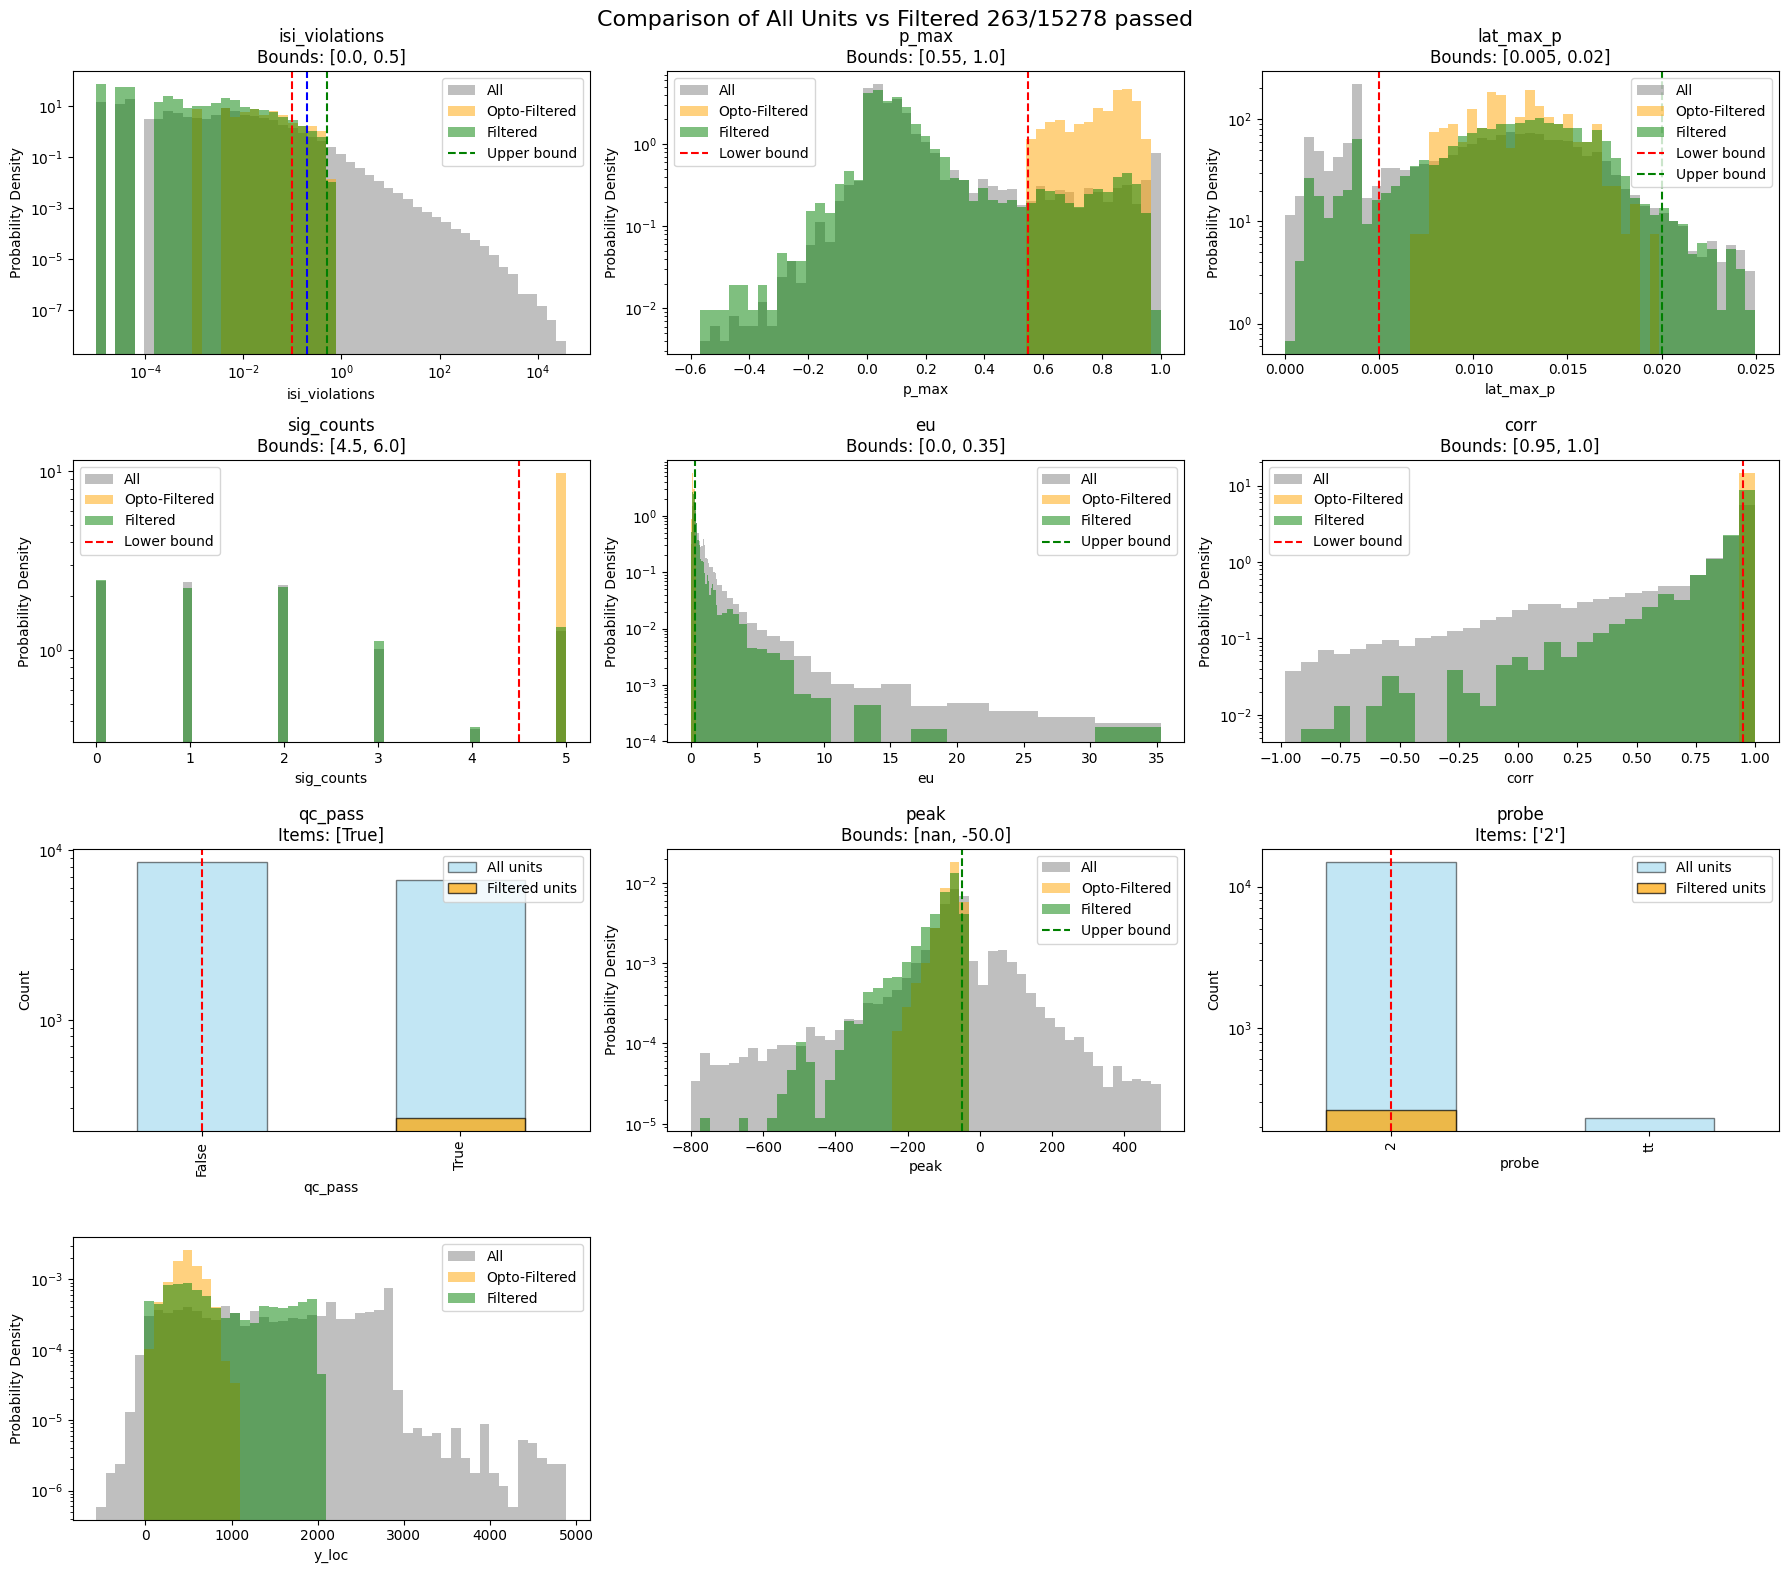

In [4]:
combined_tagged_units_filtered, combined_tagged_units, fig, axes = apply_qc(combined_tagged_units, constraints)
fig.savefig(os.path.join(target_folder, 'quality_metrics.pdf'))

In [5]:
antidromic_file = os.path.join(capsule_dirs["manuscript_fig_prep_dir"], 'antidromic_analysis', 'PrL_S1', 'combined_antidromic_results.pkl')
with open(antidromic_file, 'rb') as f:
    antidromic_df = pickle.load(f)

In [6]:
mask = np.full(len(combined_tagged_units_filtered), True)
aniNames = [parseSessionID(session_curr)[0] for session_curr in combined_tagged_units_filtered[mask]['session']]
aniNames_F = [parseSessionID(session_curr)[0] for session_curr in combined_tagged_units_filtered[mask & (combined_tagged_units_filtered['sex']=='F')]['session']]
print(f"Animals count: {len(set(aniNames))}")
print(f"Animals count (F): {len(set(aniNames_F))}")
print(f"Session count: {len(combined_tagged_units_filtered[mask]['session'].unique())}")
print(f"Unit count: {len(combined_tagged_units_filtered[mask])}")

Animals count: 18
Animals count (F): 4
Session count: 46
Unit count: 263


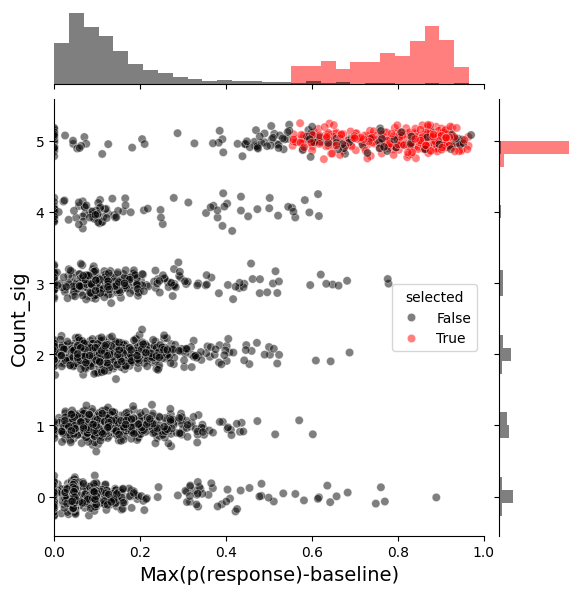

In [7]:
# opto tagged vs not
# Define color palette for groups
palette = {True: "r", False: "k"}
x_col = 'p_max'
y_col = 'sig_counts'

combined_tagged_units_plot = combined_tagged_units.copy()
combined_tagged_units_plot[y_col] = combined_tagged_units_plot[y_col]  + np.random.normal(0, 0.1, size=len(combined_tagged_units_plot[y_col]))  # add jitter to y-axis for better visibility

# Create JointGrid
g = sns.JointGrid(data=combined_tagged_units_plot[combined_tagged_units['selected_qc_only']], x=x_col, y=y_col, hue='selected', palette=palette)

# Add scatter plot in the center
g.plot_joint(sns.scatterplot, alpha=0.5)
g.ax_joint.set_xlim(0, 1)
g.ax_joint.set_xlabel('Max(p(response)-baseline)', fontsize=14)
g.ax_joint.set_ylabel('Count_sig', fontsize=14)

# Add histograms manually for each group
p_max_bins = np.linspace(0, 1, 30)
y_bins = np.linspace(combined_tagged_units_plot[combined_tagged_units['selected_qc_only']][y_col].min(), combined_tagged_units[combined_tagged_units['selected_qc_only']][y_col].max(), 30)
for qc_val, color in palette.items():
    subset = combined_tagged_units_plot[combined_tagged_units['selected_qc_only'] & (combined_tagged_units['selected'] == qc_val)]
    # Horizontal histogram for x-axis (default orientation)
    ax = g.ax_marg_x
    ax.hist(subset[x_col], bins=p_max_bins, color=color, alpha=0.5, edgecolor='none', density='True')

    # **VERTICAL histogram for y-axis** using orientation="horizontal"
    ax = g.ax_marg_y
    ax.hist(subset[y_col], bins=y_bins, color=color, alpha=0.5, edgecolor='none', density='True',  orientation='horizontal')
    # sns.histplot(y=subset['lat_max_p'], ax=g.ax_marg_y, bins=lat_max_p_bins, color=color, alpha=0.5, edgecolor='none')

plt.savefig(os.path.join(target_folder, f'opto_pass_{x_col}_{y_col}_{criteria_name}.pdf'), dpi=300, bbox_inches='tight')
# Show plot
plt.show()



## Waveform Feature Extraction

Extract quantitative features from action potential waveforms, including temporal characteristics (peak-to-trough width, repolarization time) and amplitude ratios. These features capture the diversity of neuronal biophysics across the recorded population.

In [8]:
# Extract waveform features
wf_file = os.path.join(capsule_dirs["manuscript_fig_prep_dir"], 'waveforms_np', 'combined_features.csv')
wf_features = pd.read_csv(wf_file)
# remove pc1, pc2, pc3 if they exist
wf_features = wf_features[[col for col in wf_features.columns if not col.startswith('wf_pc')]]
combined_features = wf_features.merge(combined_tagged_units_filtered[['session', 'unit', 'x_ccf', 'y_ccf', 'z_ccf', 'isi_violations']], on=['session', 'unit'], how='left')
combined_features = combined_features.merge(antidromic_df[['session', 'unit', 'tier_1']], on=['session', 'unit'], how='left')
combined_features['tier_1'] = combined_features['tier_1'].fillna(0)

In [9]:
wf_list = combined_tagged_units_filtered[f'wf{waveform_version}'].values
peak_list = combined_tagged_units_filtered[f'peak{waveform_version}'].values

# Stack waveforms into 2D array (n_units x n_timepoints)
wf_array = np.vstack(wf_list)

# Normalize each row by corresponding peak value
wf_norm = wf_array / peak_list[:, np.newaxis]  # shape: (n_units, n_timepoints)


## Waveform Collection and Normalization

Aggregate all waveforms from filtered units and normalize them for comparative analysis. Normalization accounts for differences in recording amplitude while preserving shape characteristics, enabling cross-unit comparisons.

In [21]:
# grab all tagged units and combine spike waveforms
data_type = 'curated'
target = 'soma'
selected_sessions = []
selected_units = []
all_pdf = []
all_wfs = []
all_peaks = []
curr_session = None

all_wfs = combined_tagged_units_filtered[f'wf{waveform_version}'].tolist()
# all_wfs_aligned = combined_tagged_units_filtered['wf_aligned'].tolist()
all_peaks = combined_tagged_units_filtered[f'peak{waveform_version}'].tolist()

all_wfs = np.array(all_wfs)
# all_wfs_aligned = np.array(all_wfs_aligned)
baseline = np.mean(all_wfs[:, :3], axis=1, keepdims=True) 
peaks = np.array(all_peaks).reshape(-1, 1) 
pc_time = (np.arange(90) - 30)/30000 * 1000
all_wfs_nl = (all_wfs - baseline) / ((np.squeeze(all_wfs[:, 30]) - np.squeeze(baseline))[:, np.newaxis])
all_wfs_nl_raw = all_wfs/all_wfs[:,30][:, np.newaxis]
all_wfs_nl[all_wfs_nl_raw[:, 0]>1, :] = np.nan  # remove bad waveforms
all_wfs_nl_clean = all_wfs_nl[~np.isnan(all_wfs_nl[:,0])]


In [22]:
# compute linear PCA on waveforms and append to combined features
pca = PCA(n_components=3)
pca_scores = pca.fit_transform(all_wfs_nl_clean)
pca_df = pd.DataFrame(pca_scores, columns=[f'pca_{i}' for i in range(1, 4)])
combined_features = combined_features.merge(pca_df, left_index=True, right_index=True)

## Spatial Mapping and Statistical Testing

Load anatomical coordinates for each unit and prepare for spatial visualization. Brain mesh vertices are transformed to align with stereotaxic coordinates for accurate 3D rendering of waveform properties in anatomical space.

In [23]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import numpy as np

# Custom single-color colormap: light gray → full red
colors = [(0.4, 0.4, 0.4), (0.6, 0.3, 0.3), (1.0, 0.0, 0.0)]  # RGB for low/high
cmap = LinearSegmentedColormap.from_list('custom_red', colors)

In [24]:
# load spatial info
filter = combined_features['isi_violations'].values < 0.5
ml, ap, dv = 0, 1, 2
planes = {'sag': [ap, dv], 'hor': [ml, ap], 'cor': [ml, dv]}
bregma_LPS_mm = np.array([-5.74, 5.4, -0.45])
mesh = load_mesh(mesh_file)
mesh_vertices = np.array(mesh.vertices)
mesh_vertices = mesh_vertices/1000
if 'scratch' in mesh_file:
    mesh_vertices = (mesh_vertices - np.array([216, 18, 228]))*25/1000
    mesh_vertices_lps = pir_to_lps(mesh_vertices) # convert to lps
    mesh_vertices_mm = mesh_vertices_lps
else:
    mesh_vertices_mm = mesh_vertices.copy()
    mesh_vertices_mm[:, 2] = -mesh_vertices_mm[:, 2]
    mesh_vertices_mm[:, 0] = -mesh_vertices_mm[:, 0]
    # mesh_vertices_mm = mesh_vertices[:, [0, 1, 2]]
    mesh_vertices_mm = mesh_vertices_mm - bregma_LPS_mm
mesh_vertices_mm[:, ml] = np.abs(mesh_vertices_mm[:, ml])

ccfs = combined_features[['x_ccf', 'y_ccf', 'z_ccf']].values[filter]
bregma_LPS_mm = np.array([-5.74, 5.4, -0.45])
ccfs = ccfs - bregma_LPS_mm
ccfs[:, ml] = np.abs(ccfs[:, ml])  # mirror ML to left

In [25]:
# perform spatial dependence analysis for all features
spatial_dependence_results = {}
for feature_name in wf_features.columns:
    # if numeric
    if not np.issubdtype(wf_features[feature_name].dtype, np.number):
        continue
    values = combined_features[feature_name].values
    result = spatial_dependence_summary(
        ccfs,
        values,
        k_neighbors=30,
        n_splits=5,
        permutations=2000,
        seed=42,
    )
    spatial_dependence_results[feature_name] = result

/opt/conda/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/opt/conda/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/opt/conda/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/opt/conda/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/opt/conda/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/opt/conda/lib/python3.12/site-packages/statsmodels/regression/linear_model

In [26]:
# multiple comparison correction (FDR)
from statsmodels.stats.multitest import multipletests
# for knn
p_values = [spatial_dependence_results[feat]['cv_predictability_knn']['p_value_permutation'] for feat in spatial_dependence_results.keys()]
reject, pvals_corrected, _, _ = multipletests(p_values, alpha=0.05, method='fdr_bh')
for i, feature_name in enumerate(spatial_dependence_results.keys()):
    spatial_dependence_results[feature_name]['cv_predictability_knn']['p_value_permutation_fdr'] = pvals_corrected[i]
    spatial_dependence_results[feature_name]['cv_predictability_knn']['significant_fdr'] = reject[i]
# for trend
p_values = [spatial_dependence_results[feat]['linear_trend']['p_value_permutation_r2'] for feat in spatial_dependence_results.keys()]
reject, pvals_corrected, _, _ = multipletests(p_values, alpha=0.05, method='fdr_bh')
for i, feature_name in enumerate(spatial_dependence_results.keys()):
    spatial_dependence_results[feature_name]['linear_trend']['p_value_permutation_r2_fdr'] = pvals_corrected[i]
    spatial_dependence_results[feature_name]['linear_trend']['significant_fdr'] = reject[i]
# save results
# save results
results_file = os.path.join(target_folder, f'spatial_dependence_results_{criteria_name}.pkl')
with open(results_file, 'wb') as f:
    pickle.dump(spatial_dependence_results, f)

## Feature-Space Correlation Analysis

Test for spatial dependence of waveform features across the recording region. This reveals whether specific waveform types are anatomically clustered or uniformly distributed throughout the medial prefrontal cortex.

In [27]:
focus_features_correct = [
                'post_w', 
                'trough_post_ratio_1D', 
                'post_trough_slope', 
                'pre_slope',
                'symmetry_slope_div_log',
                'symmetry_trough_dis', 
                'symmetry_inte_div_log', 
                ]
focus_features = focus_features_correct

In [28]:
norm = Normalize(vmin=0, vmax=1)
ml, ap, dv = 0, 1, 2
planes = {'sag': [ap, dv], 'hor': [ml, ap], 'cor': [ml, dv]}
bregma_LPS_mm = np.array([-5.74, 5.4, -0.45])

mesh = load_mesh(mesh_file)
mesh_vertices = np.array(mesh.vertices)
mesh_vertices = mesh_vertices/1000
if 'scratch' in mesh_file:
    mesh_vertices = (mesh_vertices - np.array([216, 18, 228]))*25/1000
    mesh_vertices_lps = pir_to_lps(mesh_vertices) # convert to lps
    mesh_vertices_mm = mesh_vertices_lps
else:
    mesh_vertices_mm = mesh_vertices.copy()
    mesh_vertices_mm[:, 2] = -mesh_vertices_mm[:, 2]
    mesh_vertices_mm[:, 0] = -mesh_vertices_mm[:, 0]
    # mesh_vertices_mm = mesh_vertices[:, [0, 1, 2]]
    mesh_vertices_mm = mesh_vertices_mm - bregma_LPS_mm
mesh_vertices_mm[:, ml] = np.abs(mesh_vertices_mm[:, ml])

# -------------------------------------------------------------------------
# Main figure: plot CCA behavioral components in CCF space
# -------------------------------------------------------------------------
filter = combined_features['isi_violations'].values < 0.5
# CCF coordinates and planes
ccfs = combined_features[['x_ccf', 'y_ccf', 'z_ccf']].values[filter]
ccfs = ccfs - bregma_LPS_mm
ccfs[:, ml] = np.abs(ccfs[:, ml])  # mirror ML to left
planes = {'sag': [ap, dv], 'hor': [ml, ap], 'cor': [ml, dv]}
bin_num = 4
# Precompute high-resolution mesh contours
mesh_contours = {
    plane_name: project_to_plane(mesh_vertices_mm, plane_axes, pitch=0.02, margin=0.5)
    for plane_name, plane_axes in planes.items()
}


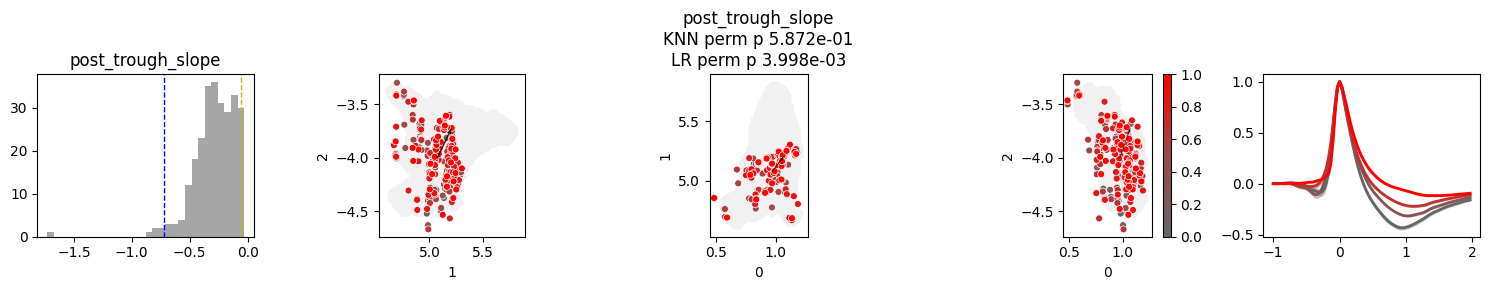

In [29]:
plot_features = ['post_trough_slope']
fig, axes = plt.subplots(len(plot_features), 5, figsize=(15, 3*len(plot_features)), squeeze=False)

for ind, feature in enumerate(plot_features):
    ax = axes[ind, 0]
    color_code = wf_features[feature].values
    ax.hist(color_code, bins=30, color='gray', alpha=0.7)
    ax.set_title(feature)
    top_90 = np.quantile(color_code, 0.98)
    bottom_10 = np.quantile(color_code, 0.02)
    ax.axvline(top_90, color='y', linestyle='--', linewidth=1)
    ax.axvline(bottom_10, color='blue', linestyle='--', linewidth=1)
    color_code_nl = color_code.copy()
    color_code_nl[color_code > top_90] = top_90
    color_code_nl[color_code < bottom_10] = bottom_10
    color_code_nl = (color_code_nl - bottom_10) / (top_90 - bottom_10)  # Normalize color code to [0, 1] using 10-90% quantiles
    # change to rank
    # color_code_nl = rankdata(color_code_nl) / len(color_code_nl)
    sort_ind = np.argsort(color_code_nl)
    # sort_ind = np.random.permutation(sort_ind)  # randomize the order within same color
    bin_edges = np.quantile(color_code, np.linspace(0, 1, bin_num + 1))
    ax = axes[ind, -1]
    for b in range(bin_num):
        bin_mask = (color_code >= bin_edges[b]) & (color_code < bin_edges[b + 1])
        mean_wf = np.nanmean(all_wfs_nl[filter][bin_mask], axis=0)
        mean_sem = np.nanstd(all_wfs_nl[filter][bin_mask], axis=0) / np.sqrt(np.sum(bin_mask))
        ax.plot(pc_time, mean_wf, label=f'Bin {b + 1} ({bin_edges[b]:.2f}-{bin_edges[b + 1]:.2f})', 
                color=cmap(b / (bin_num - 1)), linewidth=2)
        ax.fill_between(pc_time, mean_wf - mean_sem, mean_wf + mean_sem, color=cmap(b / (bin_num - 1)), 
                        alpha=0.3)
    for plane, ax in zip(planes.keys(), axes[ind, 1:]):
        # Plot the mesh
        for c in mesh_contours[plane]:
            ax.fill(c[:, 0], c[:, 1], color='lightgray', alpha=0.3, linewidth=0)
        # Plot the points
        # mesh = ax.scatter(mesh_vertices_mm[:, planes[plane][0]], mesh_vertices_mm[:, planes[plane][1]], s=0.1, edgecolor = 'none', color = 'k')
        sc = ax.scatter(ccfs[sort_ind, planes[plane][0]], ccfs[sort_ind, planes[plane][1]], c=color_code_nl[sort_ind], cmap=cmap, s=25, edgecolor=[1, 1, 1], alpha=1, linewidth=0.5)
        # add estimated arrow from linear trend
        coef = spatial_dependence_results[feature]['linear_trend']['coef_const_x_y_z']
        arrow_start = np.nanmean(ccfs, axis=0)
        arrow_vec = np.array([coef[1], coef[2], coef[3]])/np.linalg.norm([coef[1], coef[2], coef[3]])
        ax.quiver(
            arrow_start[planes[plane][0]],
            arrow_start[planes[plane][1]],
            arrow_vec[planes[plane][0]],
            arrow_vec[planes[plane][1]],
            angles='xy', scale_units='xy', scale=3,
            color='k', width=0.01, alpha=0.8
        )

        if plane == 'hor':
            if spatial_dependence_results[feature]['cv_predictability_knn']['p_value_permutation']<0.05:
                title_color = 'red'
            else:
                title_color = 'black'
            ax.set_title(
                f"{feature}\n"
                f"KNN perm p {spatial_dependence_results[feature]['cv_predictability_knn']['p_value_permutation']:.3e}\n"
                f"LR perm p {spatial_dependence_results[feature]['linear_trend']['p_value_permutation_r2']:.3e}",
                color=title_color
            )
        ax.set_xlabel(planes[plane][0])
        ax.set_ylabel(planes[plane][1])
        # set equal aspect ratio
        ax.set_aspect('equal')
        # if planes[plane][1] == dv: 
        #     ax.invert_yaxis()
            # ax.set_ylim(-5, -3)
        if plane == 'cor':
            fig.colorbar(sc, ax=ax, orientation='vertical', fraction=0.05)
            

plt.tight_layout()
save_panels(fig, target_folder, f'wf_feature_in_space_{criteria_name}', ['FigureS14b'], exts=('pdf', 'png'), dpi=300, bbox_inches='tight')
# ---- panel CSVs (rule 7: histogram/scatter/filled_psth; rule 9: S14b=post_trough_slope, S14c=symmetry_slope_div_log) ----
_name = f'wf_feature_in_space_{criteria_name}'
for _panel, _feat in {'FigureS14b': 'post_trough_slope'}.items():
    _cc = wf_features[_feat].values
    _t90 = np.quantile(_cc, 0.98); _b10 = np.quantile(_cc, 0.02)
    _ccnl = np.clip(_cc, _b10, _t90); _ccnl = (_ccnl - _b10) / (_t90 - _b10)
    save_panel_csv(columns_to_df(**{_feat: _cc}), target_folder, _name, [_panel], plot_type='histogram')
    save_panel_csv(columns_to_df(x_ccf_mm=ccfs[:, 0], y_ccf_mm=ccfs[:, 1], z_ccf_mm=ccfs[:, 2], colorcode=_cc, colorcode_nl=_ccnl), target_folder, _name, [_panel], plot_type='scatter')
    _be = np.quantile(_cc, np.linspace(0, 1, bin_num + 1))
    _bt = {'time_ms': np.asarray(pc_time)}
    for _b in range(bin_num):
        _m = (_cc >= _be[_b]) & (_cc < _be[_b + 1])
        _bt[f'bin_{_b + 1}_mean'] = np.nanmean(all_wfs_nl[filter][_m], axis=0)
        _bt[f'bin_{_b + 1}_sem'] = np.nanstd(all_wfs_nl[filter][_m], axis=0) / np.sqrt(np.sum(_m))
    save_panel_csv(columns_to_df(**_bt), target_folder, _name, [_panel], plot_type='filled_psth')
##FigureS14b##


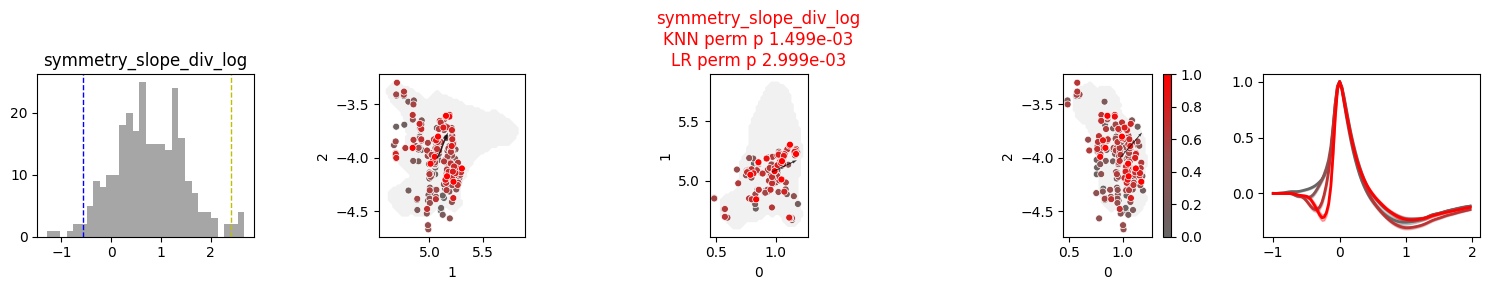

In [30]:

plot_features = ['symmetry_slope_div_log']
fig, axes = plt.subplots(len(plot_features), 5, figsize=(15, 3*len(plot_features)), squeeze=False)

for ind, feature in enumerate(plot_features):
    ax = axes[ind, 0]
    color_code = wf_features[feature].values
    ax.hist(color_code, bins=30, color='gray', alpha=0.7)
    ax.set_title(feature)
    top_90 = np.quantile(color_code, 0.98)
    bottom_10 = np.quantile(color_code, 0.02)
    ax.axvline(top_90, color='y', linestyle='--', linewidth=1)
    ax.axvline(bottom_10, color='blue', linestyle='--', linewidth=1)
    color_code_nl = color_code.copy()
    color_code_nl[color_code > top_90] = top_90
    color_code_nl[color_code < bottom_10] = bottom_10
    color_code_nl = (color_code_nl - bottom_10) / (top_90 - bottom_10)  # Normalize color code to [0, 1] using 10-90% quantiles
    # change to rank
    # color_code_nl = rankdata(color_code_nl) / len(color_code_nl)
    sort_ind = np.argsort(color_code_nl)
    # sort_ind = np.random.permutation(sort_ind)  # randomize the order within same color
    bin_edges = np.quantile(color_code, np.linspace(0, 1, bin_num + 1))
    ax = axes[ind, -1]
    for b in range(bin_num):
        bin_mask = (color_code >= bin_edges[b]) & (color_code < bin_edges[b + 1])
        mean_wf = np.nanmean(all_wfs_nl[filter][bin_mask], axis=0)
        mean_sem = np.nanstd(all_wfs_nl[filter][bin_mask], axis=0) / np.sqrt(np.sum(bin_mask))
        ax.plot(pc_time, mean_wf, label=f'Bin {b + 1} ({bin_edges[b]:.2f}-{bin_edges[b + 1]:.2f})', 
                color=cmap(b / (bin_num - 1)), linewidth=2)
        ax.fill_between(pc_time, mean_wf - mean_sem, mean_wf + mean_sem, color=cmap(b / (bin_num - 1)), 
                        alpha=0.3)
    for plane, ax in zip(planes.keys(), axes[ind, 1:]):
        # Plot the mesh
        for c in mesh_contours[plane]:
            ax.fill(c[:, 0], c[:, 1], color='lightgray', alpha=0.3, linewidth=0)
        # Plot the points
        # mesh = ax.scatter(mesh_vertices_mm[:, planes[plane][0]], mesh_vertices_mm[:, planes[plane][1]], s=0.1, edgecolor = 'none', color = 'k')
        sc = ax.scatter(ccfs[sort_ind, planes[plane][0]], ccfs[sort_ind, planes[plane][1]], c=color_code_nl[sort_ind], cmap=cmap, s=25, edgecolor=[1, 1, 1], alpha=1, linewidth=0.5)
        # add estimated arrow from linear trend
        coef = spatial_dependence_results[feature]['linear_trend']['coef_const_x_y_z']
        arrow_start = np.nanmean(ccfs, axis=0)
        arrow_vec = np.array([coef[1], coef[2], coef[3]])/np.linalg.norm([coef[1], coef[2], coef[3]])
        ax.quiver(
            arrow_start[planes[plane][0]],
            arrow_start[planes[plane][1]],
            arrow_vec[planes[plane][0]],
            arrow_vec[planes[plane][1]],
            angles='xy', scale_units='xy', scale=3,
            color='k', width=0.01, alpha=0.8
        )

        if plane == 'hor':
            if spatial_dependence_results[feature]['cv_predictability_knn']['p_value_permutation']<0.05:
                title_color = 'red'
            else:
                title_color = 'black'
            ax.set_title(
                f"{feature}\n"
                f"KNN perm p {spatial_dependence_results[feature]['cv_predictability_knn']['p_value_permutation']:.3e}\n"
                f"LR perm p {spatial_dependence_results[feature]['linear_trend']['p_value_permutation_r2']:.3e}",
                color=title_color
            )
        ax.set_xlabel(planes[plane][0])
        ax.set_ylabel(planes[plane][1])
        # set equal aspect ratio
        ax.set_aspect('equal')
        # if planes[plane][1] == dv: 
        #     ax.invert_yaxis()
            # ax.set_ylim(-5, -3)
        if plane == 'cor':
            fig.colorbar(sc, ax=ax, orientation='vertical', fraction=0.05)
            

plt.tight_layout()
save_panels(fig, target_folder, f'wf_feature_in_space_{criteria_name}', ['FigureS14c'], exts=('pdf', 'png'), dpi=300, bbox_inches='tight')
# ---- panel CSVs (rule 7: histogram/scatter/filled_psth; rule 9: S14b=post_trough_slope, S14c=symmetry_slope_div_log) ----
_name = f'wf_feature_in_space_{criteria_name}'
for _panel, _feat in {'FigureS14c': 'symmetry_slope_div_log'}.items():
    _cc = wf_features[_feat].values
    _t90 = np.quantile(_cc, 0.98); _b10 = np.quantile(_cc, 0.02)
    _ccnl = np.clip(_cc, _b10, _t90); _ccnl = (_ccnl - _b10) / (_t90 - _b10)
    save_panel_csv(columns_to_df(**{_feat: _cc}), target_folder, _name, [_panel], plot_type='histogram')
    save_panel_csv(columns_to_df(x_ccf_mm=ccfs[:, 0], y_ccf_mm=ccfs[:, 1], z_ccf_mm=ccfs[:, 2], colorcode=_cc, colorcode_nl=_ccnl), target_folder, _name, [_panel], plot_type='scatter')
    _be = np.quantile(_cc, np.linspace(0, 1, bin_num + 1))
    _bt = {'time_ms': np.asarray(pc_time)}
    for _b in range(bin_num):
        _m = (_cc >= _be[_b]) & (_cc < _be[_b + 1])
        _bt[f'bin_{_b + 1}_mean'] = np.nanmean(all_wfs_nl[filter][_m], axis=0)
        _bt[f'bin_{_b + 1}_sem'] = np.nanstd(all_wfs_nl[filter][_m], axis=0) / np.sqrt(np.sum(_m))
    save_panel_csv(columns_to_df(**_bt), target_folder, _name, [_panel], plot_type='filled_psth')
##FigureS14c##


## Multi-Feature PCA for Clustering

Perform PCA on the selected waveform features (after removing rows with missing values and z-scoring) to identify the major axes of variation in waveform morphology space. This reduces feature redundancy and highlights the key dimensions separating neuron types.

/tmp/ipykernel_1531494/3085289143.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(focus_features, rotation=45, ha='right')
/tmp/ipykernel_1531494/3085289143.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(focus_features, rotation=45, ha='right')
/tmp/ipykernel_1531494/3085289143.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(focus_features, rotation=45, ha='right')


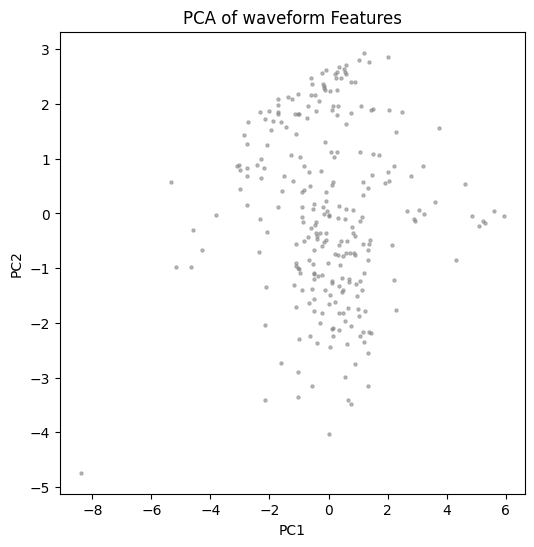

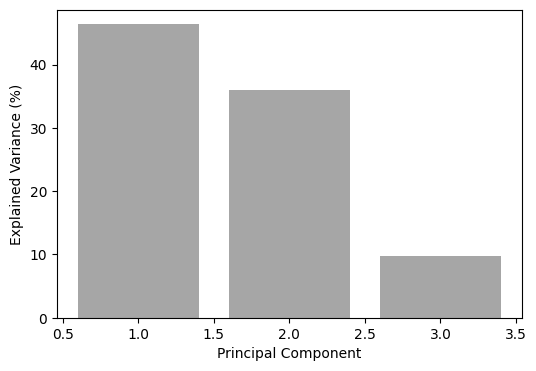

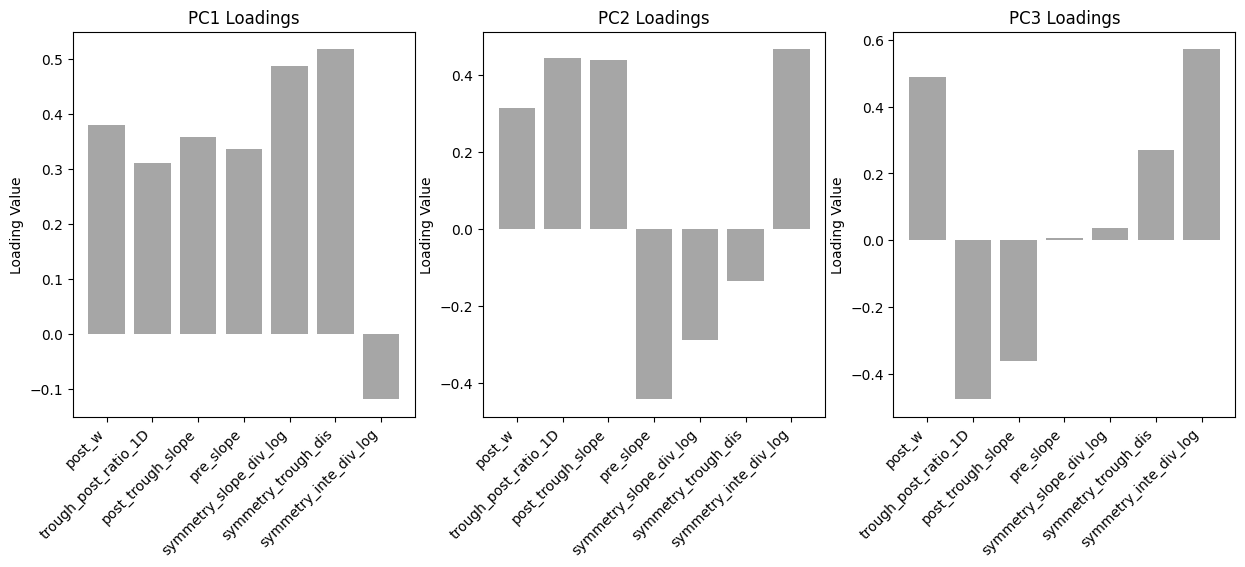

In [31]:
from sklearn.decomposition import PCA
feature_mat = combined_features[focus_features].values[filter]
# remove rows with nan
nan_ind = np.isnan(feature_mat).any(axis=1)
feature_mat = feature_mat[~nan_ind]
# zscore
from scipy.stats import zscore
feature_mat = zscore(feature_mat, axis=0, nan_policy='omit')

pca = PCA(n_components=3)
pca_result = pca.fit_transform(feature_mat)
# plot
fig = plt.figure(figsize=(6, 6))
plt.scatter(pca_result[:, 0], pca_result[:, 1], c='gray', alpha=0.5, s=5)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA of waveform Features')
# plot explained variance ratio
explained_var = pca.explained_variance_ratio_
fig = plt.figure(figsize=(6, 4))
plt.bar(range(1, len(explained_var)+1), explained_var*100, color='gray', alpha=0.7)
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance (%)')

# plot how each features contribute to each PC, plot by PC
components = pca.components_
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i in range(3):
    ax = axes[i]
    ax.bar(focus_features, components[i], color='gray', alpha=0.7)
    ax.set_title(f'PC{i+1} Loadings')
    ax.set_ylabel('Loading Value')
    ax.set_xticklabels(focus_features, rotation=45, ha='right')

In [32]:
# append pc to wf_df
pc_filtered = np.full((np.sum(filter), 3), np.nan)
pc_filtered[~nan_ind] = pca_result
combined_features['wf_pc_1'] = np.nan
combined_features['wf_pc_2'] = np.nan
combined_features['wf_pc_3'] = np.nan
combined_features.loc[filter, 'wf_pc_1'] = pc_filtered[:, 0]
combined_features.loc[filter, 'wf_pc_2'] = pc_filtered[:, 1]
combined_features.loc[filter, 'wf_pc_3'] = pc_filtered[:, 2]

# save combined features with PCs
combined_features.to_csv(os.path.join(target_folder, f'combined_features_{criteria_name}.csv'), index=False)

## Waveform Visualization by PC

Visualize how average waveform shapes vary along the first principal component. Binning units by PC1 score and plotting their mean waveforms reveals the continuous gradient of waveform morphologies captured by this dimension.

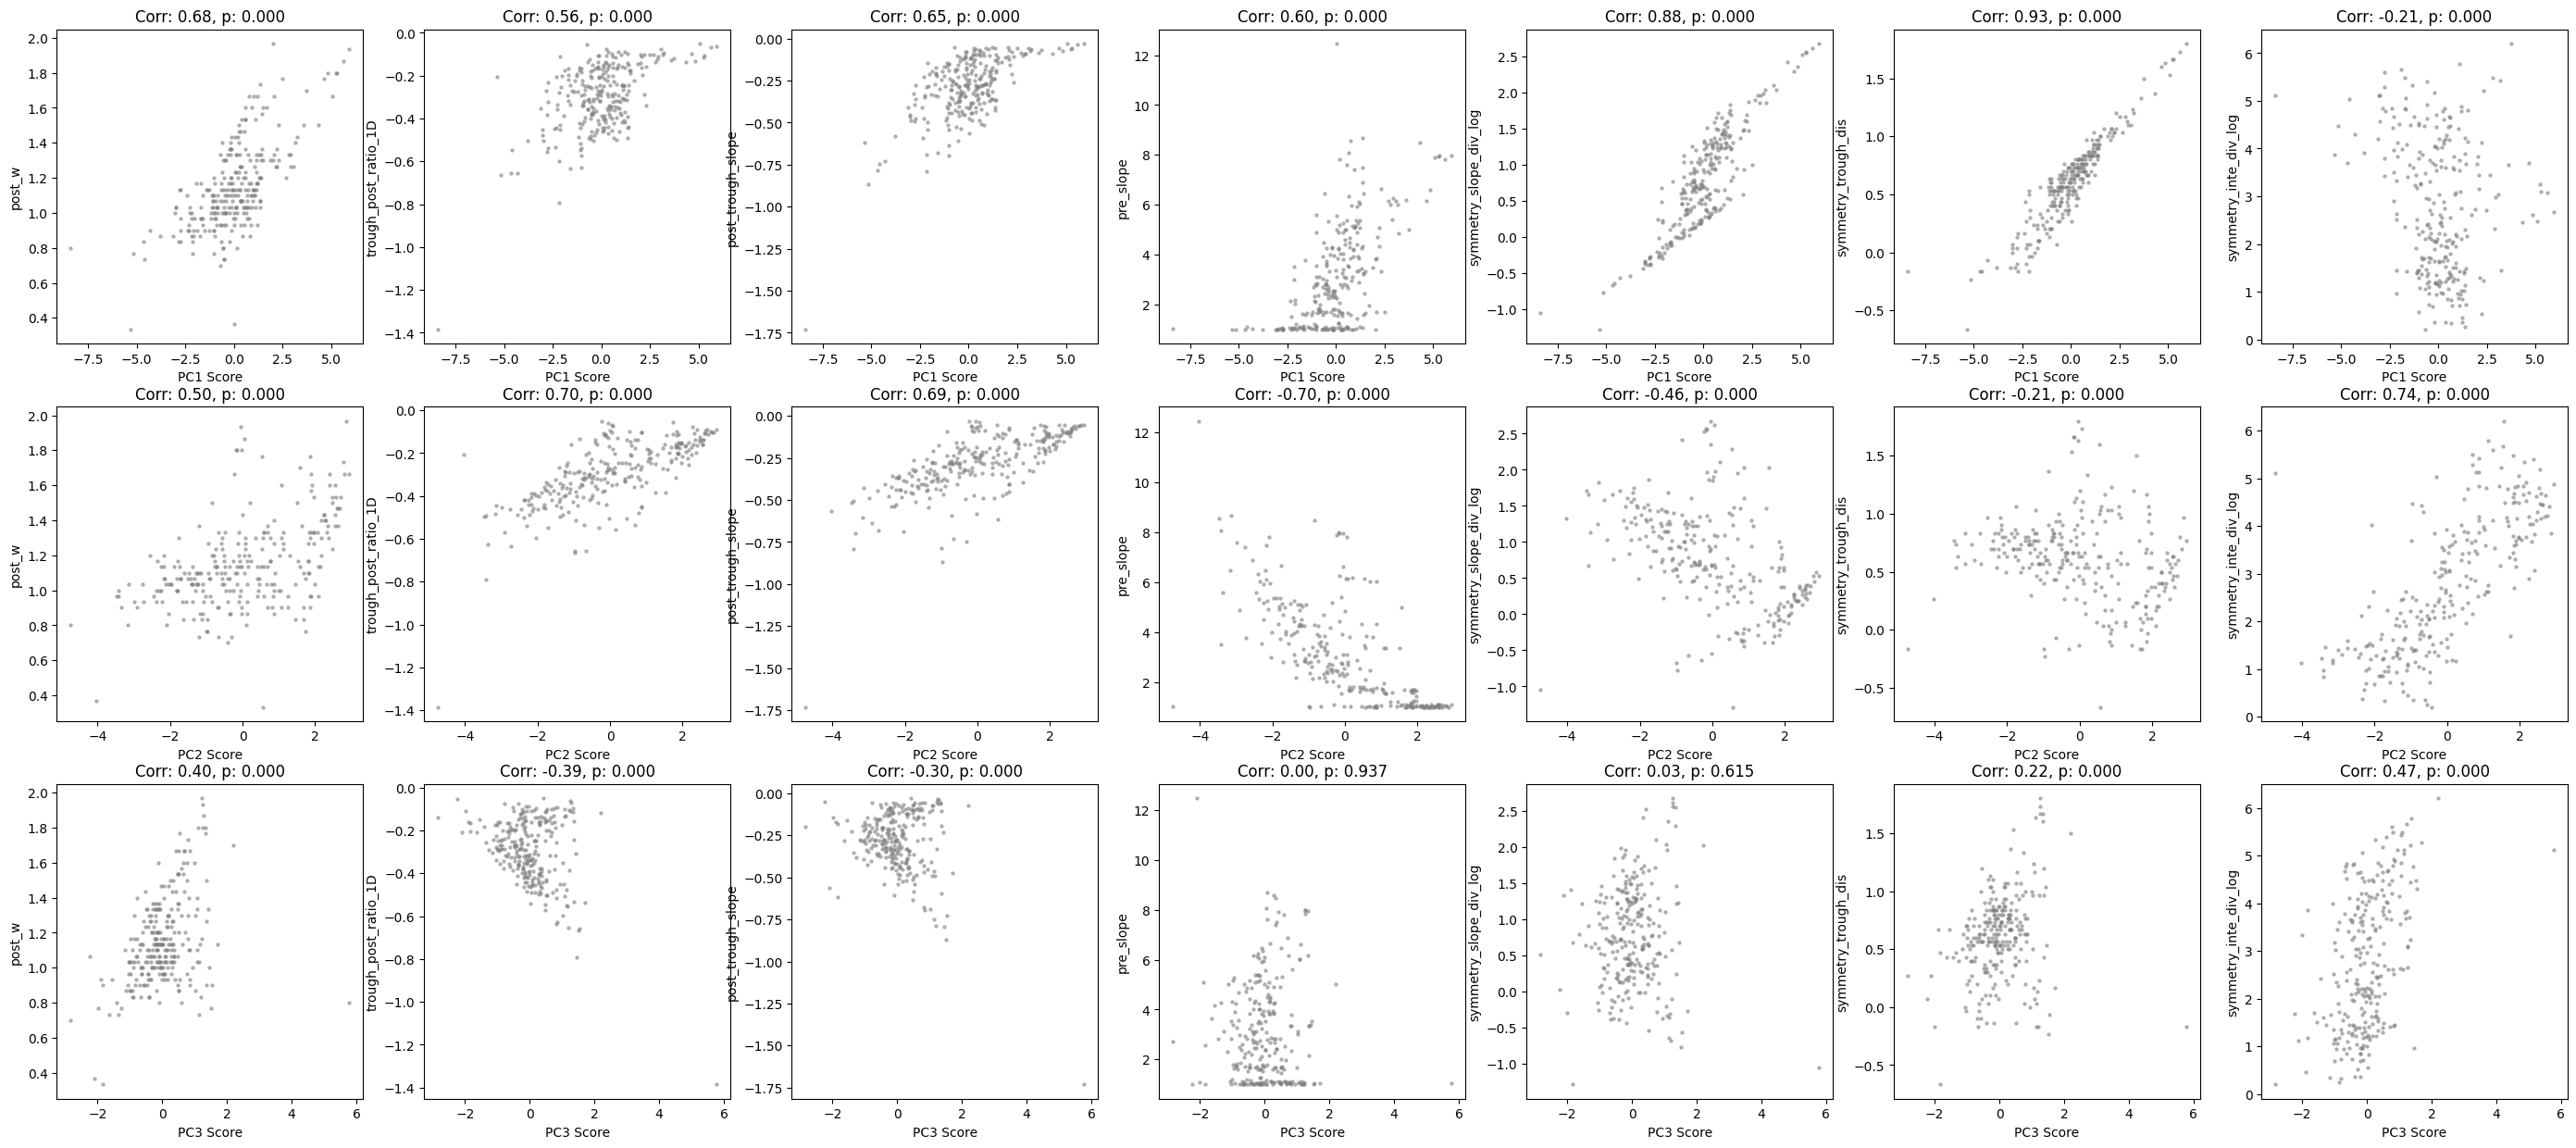

In [33]:
# scatter plot of each features for PC1 - PC3, each row is one pc, each columns if one feature, compute correlation and p value
fig, axes = plt.subplots(3, len(focus_features), figsize=(5*len(focus_features), 15))
for i in range(3):
    for j, feature in enumerate(focus_features):
        ax = axes[i, j]
        feature_values = combined_features[feature].values[filter]
        feature_values = feature_values[~nan_ind]
        ax.scatter(pca_result[:, i], feature_values, c='gray', alpha=0.5, s=5)
        ax.set_xlabel(f'PC{i+1} Score')
        ax.set_ylabel(feature)
        # compute correlation
        from scipy.stats import pearsonr
        corr, pval = pearsonr(pca_result[:, i], feature_values)
        ax.set_title(f'Corr: {corr:.2f}, p: {pval:.3f}')

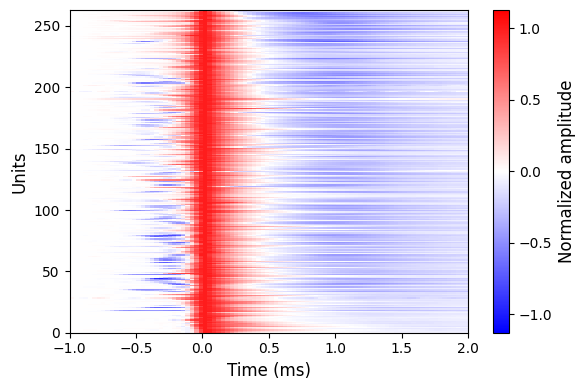

In [34]:
fig, ax = plt.subplots(figsize=(6, 4))
max_abs = np.max(np.abs(all_wfs_nl_clean))
sort_ind = np.argsort(pca_result[:, 0])
g = ax.imshow(all_wfs_nl_clean[~nan_ind, :][sort_ind], aspect='auto', cmap='bwr', vmin=-max_abs, vmax=max_abs,
               extent=[-30/30, 60/30, 0, all_wfs_nl_clean.shape[0]], interpolation='None')
cbar = plt.colorbar(g, ax=ax)
cbar.set_label('Normalized amplitude', fontsize=12)
ax.set_xlabel('Time (ms)', fontsize=12)
ax.set_ylabel('Units', fontsize=12)
fig.tight_layout()
plt.savefig(os.path.join(target_folder, f'waveform_all_heatmap_pc1_sorted.pdf'), dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(target_folder, f'waveform_all_heatmap_pc1_sorted.svg'), dpi=300, bbox_inches='tight')


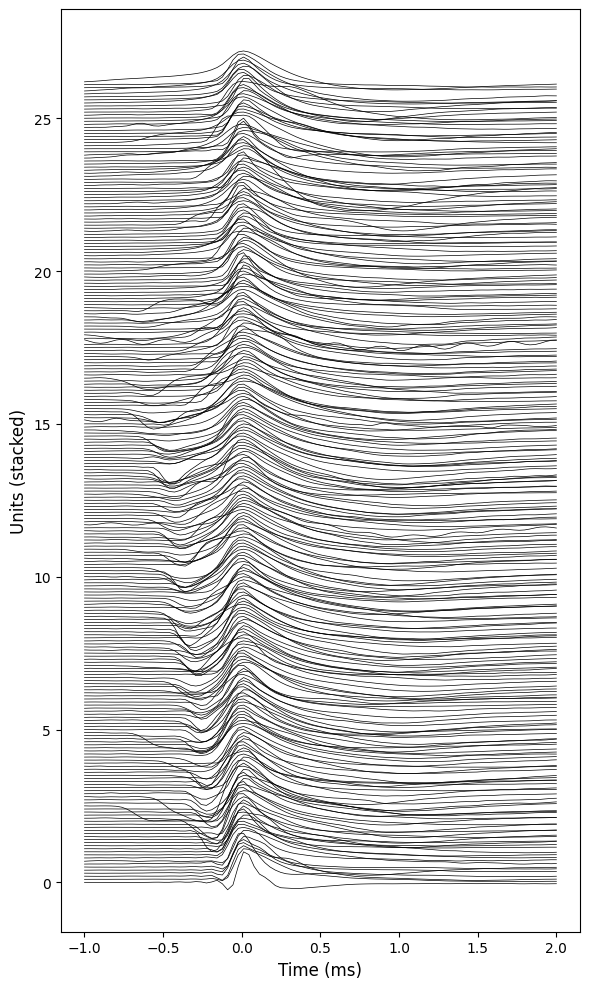

In [35]:
fig, ax = plt.subplots(figsize=(6, 10))
sort_ind = np.argsort(wf_features['pre_w'].values[filter][~nan_ind])
# sort_ind = np.argsort(pca_result[:, 0])
sorted_wfs = all_wfs_nl_clean[~nan_ind, :][sort_ind]

time_axis = np.linspace(-30/30, 60/30, sorted_wfs.shape[1])

offset =0.1   # vertical spacing between traces (tune)

for i, wf in enumerate(sorted_wfs):
    ax.plot(time_axis, wf + i * offset, color='k', linewidth=0.5)

ax.set_xlabel('Time (ms)', fontsize=12)
ax.set_ylabel('Units (stacked)', fontsize=12)

fig.tight_layout()
plt.savefig(os.path.join(target_folder, f'waveform_all_lines_sorted.svg'),
            dpi=300, bbox_inches='tight')


In [36]:
from scipy.stats import rankdata
from scipy.ndimage import binary_dilation
from skimage.measure import find_contours
import os

custom_cmap = LinearSegmentedColormap.from_list('my_cmap', 
                                               [(0, (1, 0, 0)), 
                                                (0.5, (0.5, 0.5, 0.5)), 
                                                (1.0, (0, 1, 1))])

# -------------------------------------------------------------------------
# helper: project mesh to plane and return 2D contours
# ------------------------------------------------------------------------

# -------------------------------------------------------------------------
# main plotting code
# -------------------------------------------------------------------------



# coordinates setup
ccfs = combined_features[['x_ccf', 'y_ccf', 'z_ccf']].values[filter]
ml, ap, dv = 0, 1, 2
planes = {'sag': [ap, dv], 'hor': [ml, ap], 'cor': [ml, dv]}
bregma_LPS_mm = np.array([-5.74, 5.4, -0.45])  # in mm
ccfs = ccfs - bregma_LPS_mm
ccfs[:, ml] = np.abs(ccfs[:, ml])

# precompute mesh contours for each plane (for speed)
mesh_contours = {
    plane_name: project_to_plane(mesh_vertices_mm, plane_axes, pitch=0.02, margin=0.5)
    for plane_name, plane_axes in planes.items()
}


## Waveform PC in Space

Map the principal component scores of waveform features onto anatomical coordinates. This spatial visualization reveals whether neurons with similar waveform characteristics are anatomically clustered or distributed across the recording region, providing insight into the spatial organization of cell types.

In [37]:
# test significant correlation with spatial location
spatial_dependence_results_pca = {}
for pc_ind in range(2):
    values = combined_features[f'wf_pc_{pc_ind+1}'].values
    result = spatial_dependence_summary(
        ccfs,
        values[filter],
        k_neighbors=15,
        n_splits=5,
        permutations=5000,
        seed=42,
    )
    spatial_dependence_results_pca[f'wf_pc_{pc_ind+1}'] = result

In [38]:
# multiple comparison correction (FDR)
from statsmodels.stats.multitest import multipletests
# for knn
p_values = [spatial_dependence_results_pca[f'wf_pc_{i+1}']['cv_predictability_knn']['p_value_permutation'] for i in range(2)]
reject, pvals_corrected, _, _ = multipletests(p_values, alpha=0.05, method='fdr_bh')
for i in range(2):
    feature_name = f'wf_pc_{i+1}'
    spatial_dependence_results_pca[feature_name]['cv_predictability_knn']['p_value_permutation_fdr'] = pvals_corrected[i]
    spatial_dependence_results_pca[feature_name]['cv_predictability_knn']['significant_fdr'] = reject[i]
# for trend
p_values = [spatial_dependence_results_pca[f'wf_pc_{i+1}']['linear_trend']['p_value_permutation_r2'] for i in range(2)]
reject, pvals_corrected, _, _ = multipletests(p_values, alpha=0.05, method='fdr_bh')
for i in range(2):
    feature_name = f'wf_pc_{i+1}'
    spatial_dependence_results_pca[feature_name]['linear_trend']['p_value_permutation_r2_fdr'] = pvals_corrected[i]
    spatial_dependence_results_pca[feature_name]['linear_trend']['significant_fdr'] = reject[i]
# save results
# save results
results_file = os.path.join(target_folder, f'spatial_dependence_results_pca_{criteria_name}.pkl')
with open(results_file, 'wb') as f:
    pickle.dump(spatial_dependence_results_pca, f)


```python
# from cmcrameri import cm
# custom_cmap = cm.batlowK_r
# custom_cmap = LinearSegmentedColormap.from_list('my_cmap', 
#                                                [(0, (0, 1, 1)), 
#                                                 (0.5, (0.5, 0.5, 0.5)), 
#                                                 (1.0, (1, 0, 0))])
```


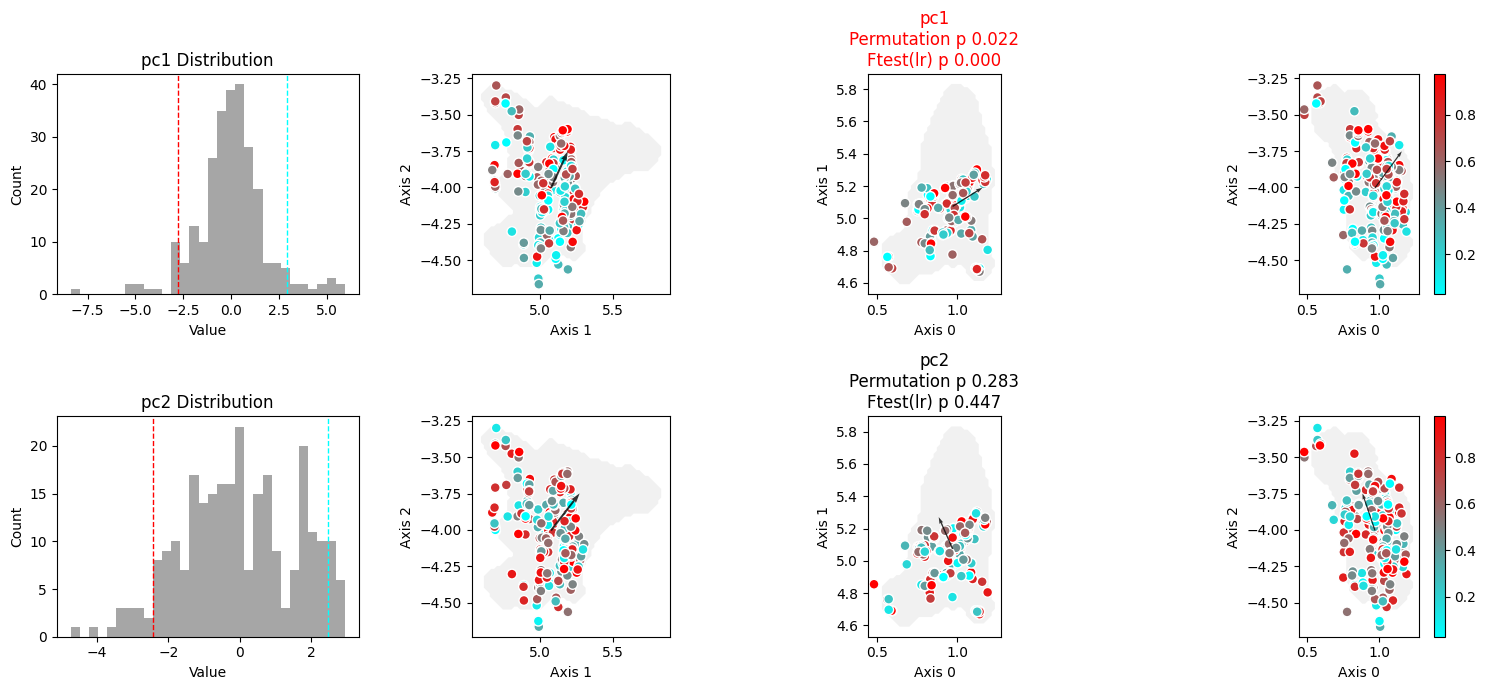

In [39]:
fig, axes = plt.subplots(2, 4, figsize=(15, 7))
version = 'pc'
custom_cmap = LinearSegmentedColormap.from_list('my_cmap', 
                                               [(0, (0, 1, 1)), 
                                                (0.5, (0.5, 0.5, 0.5)), 
                                                (1.0, (1, 0, 0))])
for i in range(2):
    # normalize PC values
    pc_values = combined_features[f'wf_{version}_{i+1}'].values[filter]
    low, high = np.nanquantile(pc_values, [0.05, 0.95])
    pc_values_nl = np.clip(pc_values, low, high)
    pc_values_nl = (pc_values_nl - low) / (high - low)
    pc_values_nl = rankdata(pc_values_nl) / len(pc_values_nl)
    sort_ind = np.argsort(pc_values_nl)
    # shuffle 
    sort_ind = np.random.permutation(len(sort_ind))

    # ---------------- histogram ----------------
    ax = axes[i, 0]
    ax.hist(pc_values, bins=30, color='gray', alpha=0.7)
    ax.axvline(low, color='r', linestyle='--', linewidth=1)
    ax.axvline(high, color='cyan', linestyle='--', linewidth=1)
    ax.set_title(f'{version}{i+1} Distribution')
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')

    # ---------------- projections ----------------
    for j, (plane_name, plane_axes) in enumerate(planes.items()):
        ax = axes[i, j + 1]

        # fill mesh projection contours
        for c in mesh_contours[plane_name]:
            ax.fill(c[:, 0], c[:, 1], color='lightgray', alpha=0.3, linewidth=0)
        # mesh = ax.scatter(mesh_vertices_mm[:, planes[plane_name][0]], mesh_vertices_mm[:, planes[plane_name][1]], s=0.1, edgecolor = 'none', color = 'k')

        # project your CCF data to the same plane
        proj_ccf = ccfs[:, plane_axes]
        sc = ax.scatter(
            proj_ccf[sort_ind, 0], proj_ccf[sort_ind, 1],
            c=pc_values_nl[sort_ind], cmap=custom_cmap,
            s=50, edgecolor=[1, 1, 1], alpha=1
        )
        # plot arrow
        coef = spatial_dependence_results_pca[f'wf_pc_{i+1}']['linear_trend']['coef_const_x_y_z']
        arrow_start = np.nanmean(ccfs, axis=0)
        arrow_vec = np.array([coef[1], coef[2], coef[3]])/np.linalg.norm([coef[1], coef[2], coef[3]])
        ax.quiver(
            arrow_start[plane_axes[0]],
            arrow_start[plane_axes[1]],
            arrow_vec[plane_axes[0]],
            arrow_vec[plane_axes[1]],
            angles='xy', scale_units='xy', scale=3,
            color='k', width=0.01, alpha=0.8
        )


        ax.set_aspect('equal')
        ax.set_xlabel(f'Axis {plane_axes[0]}')
        ax.set_ylabel(f'Axis {plane_axes[1]}')

        if plane_name == 'hor':
            if (spatial_dependence_results_pca[f'wf_pc_{i+1}']['cv_predictability_knn']['p_value_permutation'] < 0.05) or (spatial_dependence_results_pca[f'wf_pc_{i+1}']['linear_trend']['p_value_permutation_r2'] < 0.05):
                title_color = 'red'
            else:
                title_color = 'black'
            ax.set_title(
                f"{version}{i+1}\n"
                f"Permutation p {spatial_dependence_results_pca[f'wf_pc_{i+1}']['cv_predictability_knn']['p_value_permutation']:.3f}\n"
                f"Ftest(lr) p {spatial_dependence_results_pca[f'wf_pc_{i+1}']['linear_trend']['p_value_permutation_r2']:.3f}",
                color=title_color
            )
        if plane_name == 'cor':
            fig.colorbar(sc, ax=ax, orientation='vertical', fraction=0.05)

plt.tight_layout()
plt.savefig(os.path.join(target_folder, f'wf_{version}_in_space_{criteria_name}_contour.pdf'),
            dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(target_folder, f'wf_{version}_in_space_{criteria_name}_contour.svg'),
            dpi=300, bbox_inches='tight')
plt.show()


['/root/capsule/scratch/results/manuscript/figures/F_waveform_space/FigureS14f_symmetry_slope_div_log_vs_post_w_waveform_all_color_pc1.csv']

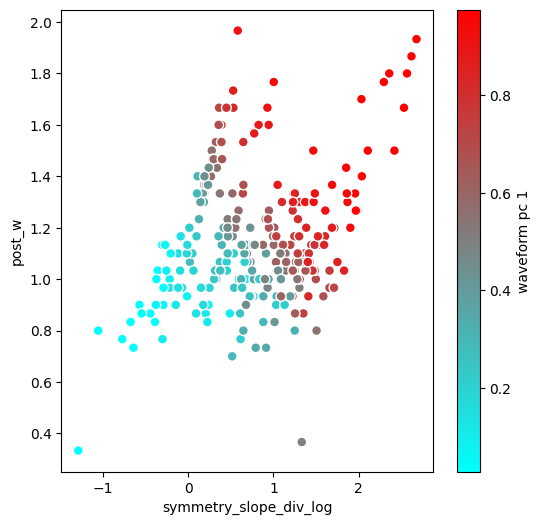

In [40]:
fig = plt.figure(figsize=(6, 6))
x_val = 'symmetry_slope_div_log'
y_val = 'post_w'

x = combined_features[x_val][filter]
# add a bit noise
# x = x + np.random.normal(0, 0.01, size=x.shape)
y = combined_features[y_val][filter]
pc_values = combined_features[f'wf_pc_1'].values[filter]
low, high = np.nanquantile(pc_values, [0.05, 0.95])
pc_values_nl = np.clip(pc_values, low, high)
pc_values_nl = (pc_values_nl - low) / (high - low)
pc_values_nl = rankdata(pc_values_nl) / len(pc_values_nl)

sc = plt.scatter(x, y, c = pc_values_nl, cmap = custom_cmap, alpha = 1, edgecolor = [1, 1, 1], s = 50)
plt.xlabel(x_val)
plt.ylabel(y_val)
plt.colorbar(sc, label='waveform pc 1')
save_panels(fig, target_folder, f'{x_val}_vs_{y_val}_{criteria_name}_color_pc1', ['FigureS14f'], exts=('pdf', 'svg'), dpi=300, bbox_inches='tight')
save_panel_csv(columns_to_df(**{x_val: np.asarray(x), y_val: np.asarray(y), 'wf_pc_1': pc_values, 'colorcode_pc1_rank': pc_values_nl}), target_folder, f'{x_val}_vs_{y_val}_{criteria_name}_color_pc1', ['FigureS14f'])
# plt.savefig(os.path.join(wf_folder, f'cca_behavioral_comp1_vs_postw_symmslope.svg'), dpi=300, bbox_inches='tight')
##FigureS14f##

Bin 1, PC1 mean: -2.133
Bin 1, PC1 mean percentile: 0.106
Bin 2, PC1 mean: -0.401
Bin 2, PC1 mean percentile: 0.384
Bin 3, PC1 mean: 0.425
Bin 3, PC1 mean percentile: 0.631
Bin 4, PC1 mean: 2.045
Bin 4, PC1 mean percentile: 0.905


['/root/capsule/scratch/results/manuscript/figures/F_waveform_space/FigureS14e_mean_wf_binned_by_pc_1_waveform_all.csv']

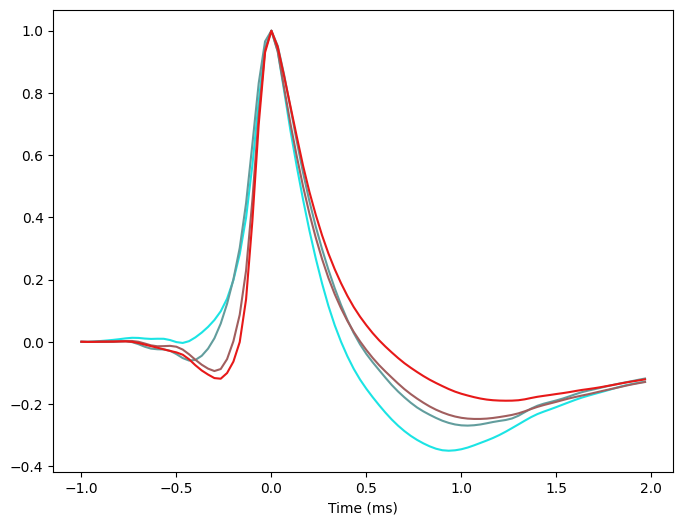

In [41]:
# plot mean waveforms, binned by pc1
num_bins = 4
fig = plt.figure(figsize=(8, 6))
pc_int = 1
bin_edges = np.quantile(combined_features[f'wf_pc_{pc_int}'][filter], np.linspace(0, 1, num_bins + 1))
# bin_edges = np.linspace(np.nanmin(combined_features[f'wf_pc_{pc_int}'][filter].values), np.nanmax(combined_features[f'wf_pc_{pc_int}'][filter].values), num_bins + 1)  # use fixed bins for better comparison across combined_features
# bin_edges = np.linespace(-1, 1, num_bins + 1)  # use fixed bins for better comparison across combined_features
# upper_limit = np.quantile(combined_features[f'wf_pc_{pc_int}'][filter], 0.95)
# lower_limit = np.quantile(combined_features[f'wf_pc_{pc_int}'][filter], 0.05)
pc_values = combined_features[f'wf_pc_{pc_int}'].values[filter]
low, high = np.nanquantile(pc_values, [0.05, 0.95])
# bin_edges = np.linspace(-1, 1, num_bins + 1)  # use fixed bins for better comparison across combined_features
pc_values_nl = np.clip(pc_values, low, high)
_csv_bins = {'time_ms': np.asarray(pc_time)}
for i in range(num_bins):
    bin_mask = (combined_features[f'wf_pc_{pc_int}'][filter] >= bin_edges[i]) & (combined_features[f'wf_pc_{pc_int}'][filter] < bin_edges[i + 1])
    value_mean = np.nanmean(combined_features[f'wf_pc_{pc_int}'][filter][bin_mask])
    # rank of value mean
    print(f'Bin {i+1}, PC{pc_int} mean: {value_mean:.3f}')
    percentile_colorcode = np.sum(pc_values_nl<value_mean)/len(pc_values_nl)
    print(f'Bin {i+1}, PC{pc_int} mean percentile: {percentile_colorcode:.3f}')
    mean_wf = np.nanmean(all_wfs_nl_clean[bin_mask], axis=0)
    plt.plot(pc_time, mean_wf, label=f'Bin {i + 1}', c = custom_cmap(percentile_colorcode))
    _csv_bins[f'bin_{i + 1}_mean'] = mean_wf
plt.xlabel('Time (ms)')

save_panels(fig, target_folder, f'mean_wf_binned_by_pc_{pc_int}_{criteria_name}', ['FigureS14e'], exts=('pdf', 'svg'))
save_panel_csv(columns_to_df(**_csv_bins), target_folder, f'mean_wf_binned_by_pc_{pc_int}_{criteria_name}', ['FigureS14e'])
##FigureS14e##

## Example Waveforms in Space

Display representative action potential waveforms at their anatomical locations within the 3D brain reconstruction. This provides concrete examples of how waveform morphology varies across different spatial positions in the medial prefrontal cortex.

In [42]:
ccfs = combined_features[['x_ccf', 'y_ccf', 'z_ccf']].values
bregma_LPS_mm = np.array([-5.74, 5.4, -0.45])
ccfs = ccfs - bregma_LPS_mm
ccfs[:, ml] = np.abs(ccfs[:, ml])  # mirror ML to left


Example units selected: [182 247   7]


/tmp/ipykernel_1531494/2410860574.py:52: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


['/root/capsule/scratch/results/manuscript/figures/F_waveform_space/FigureS14d_wf_pc1_binned_waveforms_and_examples_waveform_all_filled_psth.csv']

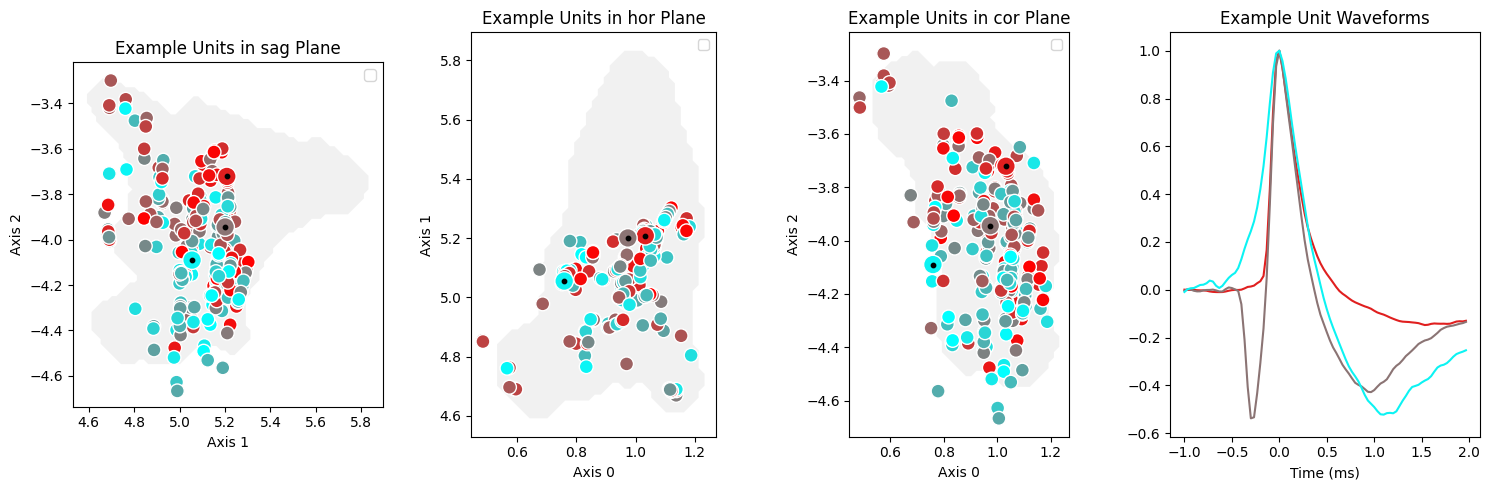

In [43]:
# pick example units from each bin and scatter in space
example_units = []
ccf_valid = np.all(~np.isnan(ccfs), axis=1)
num_bins = 3
bin_edges = np.quantile(combined_features['wf_pc_1'][filter], np.linspace(0, 1, num_bins + 1))
for i in range(num_bins):
    bin_mask = (combined_features['wf_pc_1'][filter] >= bin_edges[i]) & (combined_features['wf_pc_1'][filter] < bin_edges[i + 1])
    bin_indices = np.where(bin_mask & ccf_valid)[0]
    if len(bin_indices) > 0:
        # randomly select one unit from the bin
        example_units.append(np.random.choice(bin_indices))
example_units = np.array([np.int64(227), np.int64(292), np.int64(52)])-45
# example_units[0] = 52
# example_units[2] = 227
print('Example units selected:', example_units)
pc_values = combined_features['wf_pc_1'].values[filter]
low, high = np.nanquantile(pc_values, [0.02, 0.98])
pc_values_nl = np.clip(pc_values, low, high)
pc_values_nl = (pc_values_nl - low) / (high - low)
pc_values_nl = rankdata(pc_values_nl) / len(pc_values_nl)
sort_ind = np.argsort(pc_values_nl)
# shuffle 
sort_ind = np.random.permutation(len(sort_ind))
fig, axes = plt.subplots(1, 4, figsize=(15, 5))
for plane_ind, (plane_name, plane_axes) in enumerate(planes.items()):
    ax = axes[plane_ind]
    # fill mesh projection contours
    for c in mesh_contours[plane_name]:
        ax.fill(c[:, 0], c[:, 1], color='lightgray', alpha=0.3, linewidth=0)
    proj_ccf = ccfs[:, plane_axes]
    # mesh = ax.scatter(mesh_vertices_mm[:, planes[plane_name][0]], mesh_vertices_mm[:, planes[plane_name][1]], s=0.1, edgecolor = 'none', color = 'k')
    ax.scatter(
        proj_ccf[sort_ind, 0], proj_ccf[sort_ind, 1],
        c=pc_values_nl[sort_ind], cmap=custom_cmap,
        s=100, edgecolor=[1, 1, 1], alpha=1
    )
    sc = ax.scatter(
        proj_ccf[example_units, 0], proj_ccf[example_units, 1],
        c=pc_values_nl[example_units], cmap=custom_cmap, vmin=0, vmax=1,
        s=180, edgecolor=[1, 1, 1], alpha=1
    )
    ax.scatter(
        proj_ccf[example_units, 0], proj_ccf[example_units, 1],
        c='k',
        s=10, edgecolor=None, alpha=1
    )    
    
    ax.set_aspect('equal')
    ax.set_xlabel(f'Axis {plane_axes[0]}')
    ax.set_ylabel(f'Axis {plane_axes[1]}')
    ax.set_title(f'Example Units in {plane_name} Plane')
    ax.legend()

# plot waveform on the last axis
ax = axes[3]
for i, unit_idx in enumerate(example_units):
    mean_wf = all_wfs_nl_clean[unit_idx]
    ax.plot(pc_time, mean_wf, label=f'Bin {i + 1}', c = custom_cmap(pc_values_nl[unit_idx]))
ax.set_xlabel('Time (ms)' )
ax.set_title('Example Unit Waveforms')
plt.tight_layout()
save_panels(fig, target_folder, f'wf_pc1_binned_waveforms_and_examples_{criteria_name}', ['FigureS14d'], exts=('pdf', 'svg'), dpi=300, bbox_inches='tight')
# ---- panel CSVs (rule 7: scatter + filled_psth) ----
_name = f'wf_pc1_binned_waveforms_and_examples_{criteria_name}'
_ex_mask = np.zeros(len(pc_values_nl), dtype=bool); _ex_mask[example_units] = True
save_panel_csv(columns_to_df(x_ccf_mm=ccfs[:, 0], y_ccf_mm=ccfs[:, 1], z_ccf_mm=ccfs[:, 2], colorcode_pc1_rank=pc_values_nl, is_example=_ex_mask), target_folder, _name, ['FigureS14d'], plot_type='scatter')
_exwf = {'time_ms': np.asarray(pc_time)}
for _i, _u in enumerate(example_units):
    _exwf[f'example_{_i + 1}_unit{int(_u)}'] = all_wfs_nl_clean[_u]
save_panel_csv(columns_to_df(**_exwf), target_folder, _name, ['FigureS14d'], plot_type='filled_psth')
##FigureS14d##

## Canonical Correlation Analysis (CCA)

Perform CCA to identify relationships between waveform features and anatomical position. CCA finds linear combinations of features that are maximally correlated with spatial coordinates, revealing whether specific combinations of waveform properties predict anatomical location.

In [44]:
focus_features_cca = focus_features_correct.copy()
focus_features = focus_features_cca

CCA CCF Component 1 Coefficients:
  x_ccf: 0.3449
  y_ccf: 0.2281
  z_ccf: 0.9105
CCA CCF Component 2 Coefficients:
  x_ccf: -0.3661
  y_ccf: 0.9259
  z_ccf: -0.0933
CCA CCF Component 3 Coefficients:
  x_ccf: -0.8643
  y_ccf: -0.3012
  z_ccf: 0.4029


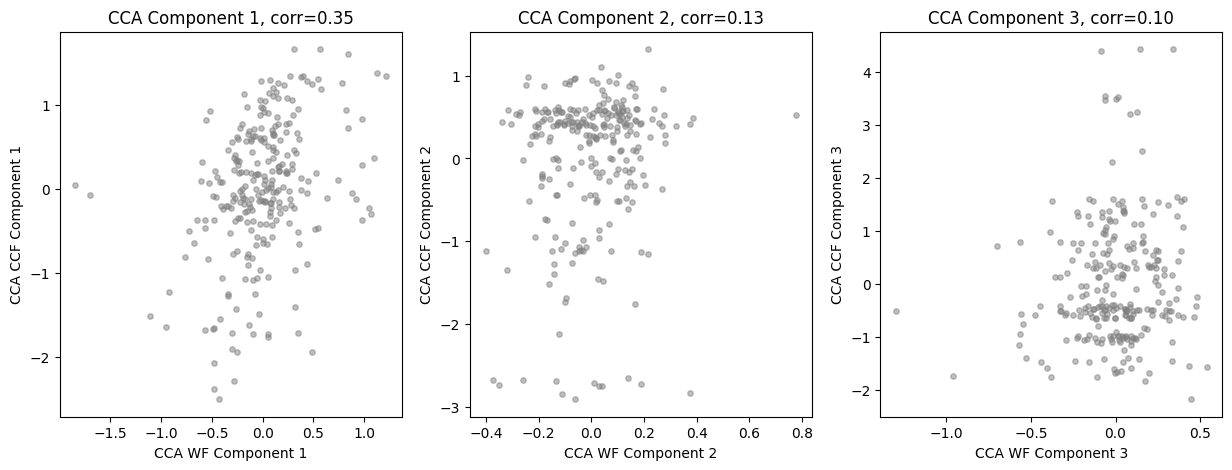

In [45]:
# cca in space
from sklearn.cross_decomposition import CCA
filters = combined_features['isi_violations'] < 0.5
focus_features_cca = focus_features
cca_wf_mat = combined_features[focus_features].values[filter]
ccf_mat = combined_features[['x_ccf', 'y_ccf', 'z_ccf']].values[filter]
bregma_LPS_mm = np.array([-5.7, 5.4, -0.45])  # in mm
ccf_mat = ccf_mat - bregma_LPS_mm
ccf_mat[:, ml] = np.abs(ccf_mat[:, ml])  # Mirror ML to left
# remove nan
nan_ind_cca = np.isnan(cca_wf_mat).any(axis=1) | np.isnan(ccf_mat).any(axis=1)
cca_wf_mat = cca_wf_mat[~nan_ind_cca]
ccf_mat = ccf_mat[~nan_ind_cca]
# zscore
cca_wf_mat = zscore(cca_wf_mat, axis=0, nan_policy='omit')
# ccf_mat = zscore(ccf_mat, axis=0, nan_policy='omit')
cca = CCA(n_components=3)
cca_result_be, cca_result_ccf = cca.fit_transform(cca_wf_mat, ccf_mat)
# plot cca result
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i in range(3):
    ax = axes[i]
    ax.scatter(cca_result_be[:, i], cca_result_ccf[:, i], c='gray', alpha=0.5, s=15)
    ax.set_xlabel(f'CCA WF Component {i+1}')
    ax.set_ylabel(f'CCA CCF Component {i+1}')
    ax.set_title(f'CCA Component {i+1}, corr={np.corrcoef(cca_result_be[:, i], cca_result_ccf[:, i])[0, 1]:.2f}')
# # print coefficients
# cca_be_coeff = cca.x_weights_
# for i in range(3):
#     print(f'CCA BE Component {i+1} Coefficients:')
#     for j, feature in enumerate(focus_features):
#         print(f'  {feature}: {cca_be_coeff[j, i]:.4f}')
# print cca ccf coeff
cca_ccf_coeff = cca.y_weights_
for i in range(3):
    print(f'CCA CCF Component {i+1} Coefficients:')
    for j, axis in enumerate(['x_ccf', 'y_ccf', 'z_ccf']):
        print(f'  {axis}: {cca_ccf_coeff[j, i]:.4f}')


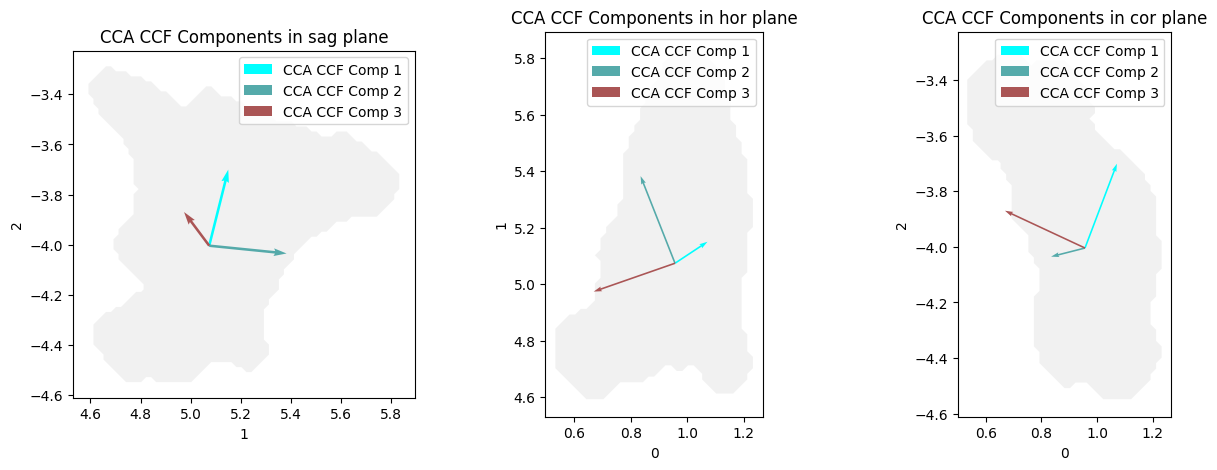

In [46]:
# plot cca ccf components weight in space as vector in ccf space with mesh
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
ccf_mat = combined_features[['x_ccf', 'y_ccf', 'z_ccf']].values[filter]
ccf_mat = ccf_mat - bregma_LPS_mm
ccf_mat[:, ml] = np.abs(ccf_mat[:, ml])  # Mirror ML to left
for plane_ind, plane in enumerate(planes.keys()):
    ax = axes[plane_ind]
    for c in mesh_contours[plane]:
        ax.fill(c[:, 0], c[:, 1], color='lightgray', alpha=0.3, linewidth=0)
    for i in range(3):
        vec = cca_ccf_coeff[:, i]
        # normalize vector for better visualization
        vec = vec / np.linalg.norm(vec)
        origin = np.nanmean(ccf_mat, axis=0)
        # origin = np.zeros(3)
        ax.quiver(origin[planes[plane][0]], origin[planes[plane][1]],
                  vec[planes[plane][0]], vec[planes[plane][1]],
                  angles='xy', scale_units='xy', scale=3, label=f'CCA CCF Comp {i+1}', color=custom_cmap(i/3))
    ax.set_xlabel(planes[plane][0])
    ax.set_ylabel(planes[plane][1])
    ax.set_aspect('equal')
    ax.set_title(f'CCA CCF Components in {plane} plane')
    ax.legend(loc='upper right')

## Bootstrapping

Use bootstrap resampling to estimate confidence intervals for CCA canonical correlations. By repeatedly resampling units with replacement and recomputing CCA, we assess the statistical reliability of the observed relationships between waveform features and spatial location.

In [47]:

# import matplotlib.pyplot as plt
# import matplotlib.cm as cm
# import numpy as np

# # ----- Setup 3 x 3 figure -----
# fig, axes = plt.subplots(2, 3, figsize=(12, 18), width_ratios=[1.5, 1.1, 1])

# # Extract and normalize CCA component vectors
# # cca_vecs = cca_ccf_coeff.copy()
# # cca_vecs = cca_vecs / np.linalg.norm(cca_vecs, axis=0, keepdims=True)

# # Optional: mean of CCF as the origin
# # origin = np.nanmean(ccf_mat, axis=0)

# axis_labels = ['x_ccf', 'y_ccf', 'z_ccf']

# for comp in range(2):   # row index → component number
#     for plane_ind, plane in enumerate(planes.keys()):  # column index → plane
#         ax = axes[comp, plane_ind]

#         ix, iy = planes[plane]

#         # anatomical mesh
#         # ax.scatter(
#         #     mesh_vertices_lps[:, ix],
#         #     mesh_vertices_lps[:, iy],
#         #     color='lightgray',
#         #     alpha=0.1,
#         #     s=0.2
#         # )
#         for c in mesh_contours[plane]:
#             ax.fill(c[:, 0], c[:, 1], color='lightgray', alpha=0.3, linewidth=0)

#         # ax.quiver(origin[planes[plane][0]], origin[planes[plane][1]],
#         #     vec[planes[plane][0]], vec[planes[plane][1]],
#         #     angles='xy', scale_units='xy', scale=3, label=f'CCA CCF Comp {i+1}', color=cm.viridis(i/3))

#         # ---------- BOOTSTRAP VECTOR CLOUD ----------
#         for b in range(n_boot):
#             vec = boot_yw_norm[b, :, comp]

#             ax.quiver(
#                 origin[ix], origin[iy],
#                 vec[ix], vec[iy],
#                 angles='xy',
#                 scale_units='xy',
#                 scale=1/0.25,
#                 color=[0.5, 0.5, 0.5],
#                 alpha=0.3,      # transparent bootstrap vectors
#                 width=0.001,
#                 linewidth=0.01
#             )

#         # ---------- ORIGINAL CCA VECTOR (THICK) ----------
#         vec0 = cca_vecs[:, comp].copy()

#         ax.quiver(
#             origin[ix], origin[iy],
#             vec0[ix], vec0[iy],
#             angles='xy',
#             scale_units='xy',
#             scale=1/0.25,
#             color=cm.viridis(comp / 3),
#             width=0.003,
#             linewidth=0.25,
#             label=f'Comp {comp+1}'
#         )

#         # labels & style
#         ax.set_xlabel(axis_labels[ix])
#         ax.set_ylabel(axis_labels[iy])
#         ax.set_aspect('equal')

#         if comp == 0:
#             ax.set_title(f'{plane}')

#         if plane_ind == 0:
#             ax.set_ylabel(f'Comp {comp+1}\n{axis_labels[iy]}')

#         # ax.legend(loc='upper left')

# plt.tight_layout()
# plt.savefig(
#     os.path.join(target_folder, 'CCA_CCF_components_bootstrap_3x3.pdf'),
#     bbox_inches='tight'
# )
# plt.show()



```python
# import matplotlib.cm as cm
# from matplotlib.patches import Ellipse

# # ----- Setup 2 x 3 figure -----
# fig, axes = plt.subplots(2, 3, figsize=(12, 8))

# axis_labels = ['x_ccf', 'y_ccf', 'z_ccf']
# n_se = 3  # 1 standard error ellipse
# for comp in range(2):   # rows
#     for plane_ind, plane in enumerate(planes.keys()):  # columns
#         ax = axes[comp, plane_ind]
#         ix, iy = planes[plane]

#         # Draw anatomical background
#         for c in mesh_contours[plane]:
#             ax.fill(c[:, 0], c[:, 1], color='lightgray', alpha=0.3, linewidth=0)

#         # ----------------------------
#         # BOOTSTRAP VECTOR VARIABILITY
#         # ----------------------------
#         # Collect bootstrap vectors for this component
#         boot_vecs = boot_yw_norm[:, :, comp]
#         # Mean vector
#         mean_vec = np.nanmean(boot_vecs, axis=0)
#         mean_vec /= np.linalg.norm(mean_vec)

#         # Project all bootstrap vectors to the plane (ix, iy)
#         vecs_2d = boot_vecs[:, [ix, iy]]
#         mean_2d = mean_vec[[ix, iy]]

#         # Compute 2D covariance for cone/ellipse (bootstrapped spread)
#         cov = np.cov(vecs_2d.T)

#         # Convert covariance to *standard error* ellipse
#         eigvals, eigvecs = np.linalg.eigh(cov / n_boot)  # divide by n_boot for SE

#         # Scale by desired number of SEs (e.g., 1 → 1 SE, 2 → 95% CI)
#         width, height = 2 * n_se * np.sqrt(eigvals)
#         angle = np.degrees(np.arctan2(*eigvecs[:, 1][::-1]))

#         scale = 1/0.25  # scaling factor for arrow length
#         end_x = origin[ix] + mean_2d[0] / scale
#         end_y = origin[iy] + mean_2d[1] / scale

#         # Ellipse centered at arrow tip
#         ellipse = Ellipse(
#             xy=(end_x, end_y),
#             width=width, height=height, angle=angle,
#             edgecolor=cm.viridis(comp / 3),
#             facecolor=cm.viridis(comp / 3),
#             alpha=0.25, lw=1.2
#         )
#         ax.add_patch(ellipse)

#         # ----------------------------
#         # MEAN VECTOR (CENTRAL AXIS)
#         # ----------------------------
#         ax.quiver(
#             origin[ix], origin[iy],
#             mean_2d[0], mean_2d[1],
#             angles='xy', scale_units='xy', scale=scale,
#             color=cm.viridis(comp / 3),
#             width=0.004, linewidth=1.0,
#             label=f'Comp {comp+1}'
#         )

#         # ----------------------------
#         # OPTIONAL: TRUE CCA VECTOR
#         # ----------------------------
#         # true_vec = cca_vecs[:, comp]
#         # ax.quiver(
#         #     origin[ix], origin[iy],
#         #     true_vec[ix], true_vec[iy],
#         #     angles='xy', scale_units='xy', scale=1/0.25,
#         #     color='black', width=0.002, linewidth=0.5,
#         #     alpha=0.8, label='Original CCA'
#         # )

#         # labels & style
#         ax.set_xlabel(axis_labels[ix])
#         ax.set_ylabel(axis_labels[iy])
#         ax.set_aspect('equal')

#         if comp == 0:
#             ax.set_title(f'{plane}')

#         if plane_ind == 0:
#             ax.set_ylabel(f'Comp {comp+1}\n{axis_labels[iy]}')

#         ax.legend(loc='upper left', fontsize=8)

# plt.tight_layout()
# plt.savefig(
#     os.path.join(target_folder, f'CCA_CCF_components_bootstrap_{n_se}_SE_cones.pdf'),
#     bbox_inches='tight'
# )
# plt.show()
```


## Shuffling Control Analysis

Perform permutation testing by randomly shuffling the correspondence between waveform features and spatial coordinates. This generates a null distribution of CCA correlations under the assumption of no true relationship, allowing us to test whether the observed correlations are statistically significant.

In [48]:
# create a functions that takes in cca_be_mat and ccf_mat and performs the entire cca with bootstrap and returns the cca results with ci
# outputs: cca_result_be, cca_result_ccf, xw_low, xw_high, yw_low, yw_high, boot_xw, boot_yw, cca_x_weights, cca_y_weights
from collections import defaultdict
def vector_to_angles(v, off_set = 0.2):
    """Return (phi_new, theta) where φ=1 rad maps to φ_new=0."""
    x, y, z = v

    # raw azimuth φ in [0, 2π)
    phi = np.arctan2(y, x)
    if phi < 0:
        phi += 2 * np.pi

    # shift reference so φ=1 → φ_new=0
    phi_new = phi + off_set
    if phi_new < 0:
        phi_new += 2 * np.pi
    elif phi_new >= 2*np.pi:
        phi_new -= 2 * np.pi

    # elevation θ stays the same
    theta = np.arctan2(z, np.sqrt(x*x + y*y))

    return phi_new, theta

def express_in_basis(v, a):
    """
    Express vector v in a new coordinate system where:
      - z-axis is aligned with vector a
      - x- and y-axes are orthogonal to a (right-handed system)

    Returns:
        v_new : np.ndarray
            Coordinates of v in the new (x, y, z=a) basis
        R : np.ndarray
            3×3 rotation matrix (columns are the new basis vectors)
    """
    a = np.asarray(a, dtype=float)
    v = np.asarray(v, dtype=float)

    # Normalize z-axis (the reference direction)
    z_axis = a / np.linalg.norm(a)

    # Pick a stable arbitrary vector not parallel to z
    if abs(z_axis[0]) < 0.9:
        tmp = np.array([1, 0, 0])
    else:
        tmp = np.array([0, 1, 0])

    # Build x-axis orthogonal to z (Gram–Schmidt)
    x_axis = tmp - np.dot(tmp, z_axis) * z_axis
    x_axis /= np.linalg.norm(x_axis)

    # y-axis = z × x (right-handed system)
    y_axis = np.cross(z_axis, x_axis)
    y_axis /= np.linalg.norm(y_axis)

    # Rotation matrix: columns are new basis vectors
    R = np.column_stack([x_axis, y_axis, z_axis])

    # Express v in new basis
    v_new = R.T @ v

    return v_new, R
    
def perform_cca_with_bootstrap(cca_be_mat, ccf_mat, n_samples=5000, n_boot=1000, alpha=0.05, return_all=False):
    # Fit original CCA
    cca = CCA(n_components=2)
    cca.fit(cca_be_mat, ccf_mat)
    xw = cca.x_weights_
    yw = cca.y_weights_

    cca_result_be, cca_result_ccf = cca.fit_transform(cca_be_mat, ccf_mat)

    cca_vecs = yw / np.linalg.norm(yw, axis=0, keepdims=True)

    # Bin data into 3D voxels
    coords = ccf_mat
    n_bins_xyz = (3, 3, 4)
    bins = [
        np.linspace(coords[:, i].min()-0.1, coords[:, i].max()+0.1, n_bins_xyz[i] + 1)
        for i in range(3)
    ]
    xbin = np.digitize(coords[:, 0], bins[0]) - 1
    ybin = np.digitize(coords[:, 1], bins[1]) - 1
    zbin = np.digitize(coords[:, 2], bins[2]) - 1

    voxel_map = defaultdict(list)
    for i in range(len(coords)):
        v = (xbin[i], ybin[i], zbin[i])
        voxel_map[v].append(i)

    valid_voxels = [v for v in voxel_map if len(voxel_map[v]) > 0]
    counts = np.array([len(voxel_map[v]) for v in valid_voxels])
    total_count = counts.sum()
    samples_per_voxel = np.maximum(1, np.floor((counts / total_count) * n_samples).astype(int))

    # Bootstrap loop
    rng = np.random.default_rng(4)
    boot_xw = np.zeros((n_boot, cca_be_mat.shape[1], 2))
    boot_yw = np.zeros((n_boot, 3, 2))

    for b in range(n_boot):
        indices = []
        for vox_idx, voxel in enumerate(valid_voxels):
            n_draw = voxel_map[voxel].__len__()
            picked = rng.choice(
                voxel_map[voxel],
                size=n_draw,
                replace=True
            )
            indices.extend(picked)
        indices = np.array(indices)
        Xb = cca_be_mat[indices]
        Yb = ccf_mat[indices]
        cca_b = CCA(n_components=2)
        cca_b.fit(Xb, Yb)
        boot_xw[b] = cca_b.x_weights_
        boot_yw[b] = cca_b.y_weights_

    # Sign alignment
    boot_yw_aligned = boot_yw.copy()
    boot_xw_aligned = boot_xw.copy()

    boot_yw_norm = (
        boot_yw_aligned /
        np.linalg.norm(boot_yw_aligned, axis=1, keepdims=True)
    )

    for comp in range(2):
        ref = cca_vecs[:, comp]
        for b in range(n_boot):
            if np.dot(boot_yw_norm[b, :, comp], ref) < 0:
                boot_yw_aligned[b, :, comp] *= -1
                boot_xw_aligned[b, :, comp] *= -1




    boot_yw = boot_yw_aligned
    boot_xw = boot_xw_aligned

    boot_yw = (
        boot_yw /
        np.linalg.norm(boot_yw, axis=1, keepdims=True)
    )

    # compute CI bounds
    xw_low  = np.percentile(boot_xw, 100 * alpha/2, axis=0)
    xw_high = np.percentile(boot_xw, 100 * (1 - alpha/2), axis=0)
    yw_low  = np.percentile(boot_yw, 100 * alpha/2, axis=0)
    yw_high = np.percentile(boot_yw, 100 * (1 - alpha/2), axis=0)

    # save correlation of cca results
    corrs = np.corrcoef(cca_result_be.T, cca_result_ccf.T)
    corrs = np.diag(corrs[:2, 2:])

    # Compute angles 
    phi_boot = np.zeros((n_boot, 2))
    theta_boot = np.zeros((n_boot, 2))
    # mean vector
    v_mean = np.nanmean(boot_yw, axis=0)
    ang_mean_0 = np.arctan2(v_mean[1, 0], v_mean[0, 0])
    # ang_mean_1 = np.arctan2(v_mean[1, 1], v_mean[0, 1])
    # for comp 0
    comp = 0
    for b in range(n_boot):
        v = boot_yw[b, :, comp]
        phi_boot[b, comp], theta_boot[b, comp] = vector_to_angles(v, off_set=np.pi-ang_mean_0)
    # for comp 1
    comp = 1
    v_proj = np.zeros((n_boot, 3))
    for b in range(n_boot):
        # project v onto plane orthogonal to component 0
        v_proj[b, :], R = express_in_basis(boot_yw[b, :, comp], cca_vecs[:, 0])
        # convert projected 2D vector to angles
    # mean vector
    v_mean_1 = np.nanmean(v_proj, axis=0)
    ang_mean_1 = np.arctan2(v_mean_1[1], v_mean_1[0])
    for b in range(n_boot):
        phi_boot[b, comp], theta_boot[b, comp] = vector_to_angles(v_proj[b, :], off_set=np.pi - ang_mean_1)

    # compute angles for original CCA vectors
    phi_orig = np.zeros(2)
    theta_orig = np.zeros(2)
    # for comp 0
    comp = 0
    v0 = cca_vecs[:, comp]   # normalized
    phi_orig[comp], theta_orig[comp] = vector_to_angles(v0, off_set=-0.5)
    # for comp 1
    comp = 1
    v1 = cca_vecs[:, comp]
    v1_proj, R = express_in_basis(v1, cca_vecs[:, 0])
    phi_orig[comp], theta_orig[comp] = vector_to_angles(v1_proj, off_set=1)


    # variance for directions:
    cov_matrix_comp0 = np.cov((boot_yw[:, :, 0]).T)
    cov_matrix_comp1 = np.cov((boot_yw[:, :, 1]).T)
    # eigen decomposition
    eigvals_vec_0, eigvecs_vec_0 = np.linalg.eig(cov_matrix_comp0)
    max_idx0 = np.argmax(eigvals_vec_0)
    principal_dir0_vec = eigvecs_vec_0[:, max_idx0]
    principal_var0_vec = eigvals_vec_0[max_idx0]

    eigvals_vec_1, eigvecs_vec_1 = np.linalg.eig(cov_matrix_comp1)
    max_idx1 = np.argmax(eigvals_vec_1)
    principal_dir1_vec = eigvecs_vec_1[:, max_idx1]
    principal_var1_vec = eigvals_vec_1[max_idx1]

    # variance for angles:
    # calcuate covariance of phi and theta
    cov_matrix_comp0 = np.cov(theta_boot[:, 0], phi_boot[:, 0])
    cov_matrix_comp1 = np.cov(theta_boot[:, 1], phi_boot[:, 1])
    # eigen decomposition
    # For component 0
    eigvals_ang_0, eigvecs_ang_0 = np.linalg.eig(cov_matrix_comp0)
    max_idx0 = np.argmax(eigvals_ang_0)
    principal_dir0_ang = eigvecs_ang_0[:, max_idx0]
    principal_var0_ang = eigvals_ang_0[max_idx0]

    # For component 1
    eigvals_ang_1, eigvecs_ang_1 = np.linalg.eig(cov_matrix_comp1)
    max_idx1 = np.argmax(eigvals_ang_1)
    principal_dir1_ang = eigvecs_ang_1[:, max_idx1]
    principal_var1_ang = eigvals_ang_1[max_idx1]
    result = {'corrs': corrs,
                # 'cca_result_be': cca_result_be,
                # 'cca_result_ccf': cca_result_ccf,
                # 'xw_low': xw_low,
                # 'xw_high': xw_high,
                # 'yw_low': yw_low,
                # 'yw_high': yw_high,
                # 'boot_xw': boot_xw,
                # 'boot_yw': boot_yw,
                'cca_x_weights': cca.x_weights_,
                'cca_y_weights': cca.y_weights_,
                'cca_vecs': cca_vecs,
                # 'phi_boot': phi_boot,
                # 'theta_boot': theta_boot,
                'phi_orig': phi_orig,
                'theta_orig': theta_orig,
                # 'var_phi': var_phi,
                # 'var_theta': var_theta,
                'eigvals_vec_0': np.sort(eigvals_vec_0)[::-1],
                # 'eigvecs_vec_0': eigvecs_vec_0,
                'eigvals_vec_1': np.sort(eigvals_vec_1)[::-1], 
                # 'eigvecs_vec_1': eigvecs_vec_1,
                'eigvals_ang_0': np.sort(eigvals_ang_0)[::-1],
                # 'eigvecs_ang_0': eigvecs_ang_0,
                'eigvals_ang_1': np.sort(eigvals_ang_1)[::-1],
                # 'eigvecs_ang_1': eigvecs_ang_1,
                }
    if not return_all:
        return result
    else:
        result.update({
            'boot_xw': boot_xw,
            'boot_yw': boot_yw,
            'phi_boot': phi_boot,
            'theta_boot': theta_boot,
        })
        return result
        
        
def shuffle_cca_with_bootstrap(cca_be_mat, ccf_mat, n_samples=5000, n_boot=1000, alpha=0.05):
    # shuffle the cca_be_mat
    shuffled_cca_be_mat = cca_be_mat.copy()
    np.random.shuffle(shuffled_cca_be_mat)
    # perform cca with bootstrap
    results = perform_cca_with_bootstrap(shuffled_cca_be_mat, ccf_mat, n_samples, n_boot, alpha, return_all=False)
    return results

In [49]:

# focus_features_cca = focus_features+['beh_umap_1', 'beh_umap_2']
filter = combined_features['isi_violations'] < 0.5
cca_be_mat = combined_features[focus_features].values[filter]

bregma_LPS_mm = np.array([-5.7, 5.4, -0.45])
ccf_mat = combined_features[['x_ccf', 'y_ccf', 'z_ccf']].values[filter]
ccf_mat = ccf_mat - bregma_LPS_mm
ccf_mat[:, ml] = np.abs(ccf_mat[:, ml])  # Mirror ML to left

# remove nan
nan_ind_cca = np.isnan(cca_be_mat).any(axis=1) | np.isnan(ccf_mat).any(axis=1)
cca_be_mat = cca_be_mat[~nan_ind_cca]
ccf_mat = ccf_mat[~nan_ind_cca]

# Convert to ranked values column-wise
ccf_mat_ranked = np.zeros_like(ccf_mat)
for i in range(ccf_mat.shape[1]):
    ccf_mat_ranked[:, i] = rankdata(ccf_mat[:, i], method='average')
# zscore
cca_be_mat = zscore(cca_be_mat, axis=0, nan_policy='omit')
# ccf_mat = features_combined[['x_ccf', 'y_ccf', 'z_ccf']].values[filter][~nan_ind_cca]
n_boot = 1500
result_ori = perform_cca_with_bootstrap(cca_be_mat, ccf_mat, n_samples=ccf_mat.shape[0], n_boot=n_boot, alpha=0.05, return_all=True)
# result = shuffle_cca_with_bootstrap(cca_be_mat, ccf_mat, n_samples=1000, n_boot=1000, alpha=0.05)

In [50]:
from joblib import Parallel, delayed
parallel_results = Parallel(n_jobs=10)(
    delayed(shuffle_cca_with_bootstrap)(cca_be_mat, ccf_mat, n_samples=ccf_mat.shape[0], n_boot=1500, alpha=0.05)
    for _ in range(500)
)

/opt/conda/lib/python3.12/site-packages/sklearn/cross_decomposition/_pls.py:104: ConvergenceWarning: Maximum number of iterations reached
  warnings.warn("Maximum number of iterations reached", ConvergenceWarning)
/opt/conda/lib/python3.12/site-packages/sklearn/cross_decomposition/_pls.py:104: ConvergenceWarning: Maximum number of iterations reached
  warnings.warn("Maximum number of iterations reached", ConvergenceWarning)


In [51]:
# make results into df
shuffle_eigvals_vec_0 = np.array([res['eigvals_vec_0'] for res in parallel_results])
shuffle_eigvals_vec_1 = np.array([res['eigvals_vec_1'] for res in parallel_results])
shuffle_eigvals_ang_0 = np.array([res['eigvals_ang_0'] for res in parallel_results])
shuffle_eigvals_ang_1 = np.array([res['eigvals_ang_1'] for res in parallel_results])
shuffle_corr_0 = np.array([res['corrs'][0] for res in parallel_results])
shuffle_corr_1 = np.array([res['corrs'][1] for res in parallel_results])
import pandas as pd
shuffle_results_df = pd.DataFrame({
    'eigvals_vec_0_1': shuffle_eigvals_vec_0[:, 0],
    'eigvals_vec_0_2': shuffle_eigvals_vec_0[:, 1],
    'eigvals_vec_1_1': shuffle_eigvals_vec_1[:, 0],
    'eigvals_vec_1_2': shuffle_eigvals_vec_1[:, 1],
    'eigvals_ang_0_1': shuffle_eigvals_ang_0[:, 0],
    'eigvals_ang_0_2': shuffle_eigvals_ang_0[:, 1],
    'eigvals_ang_1_1': shuffle_eigvals_ang_1[:, 0],
    'eigvals_ang_1_2': shuffle_eigvals_ang_1[:, 1],
    'corr_0': shuffle_corr_0,
    'corr_1': shuffle_corr_1
})


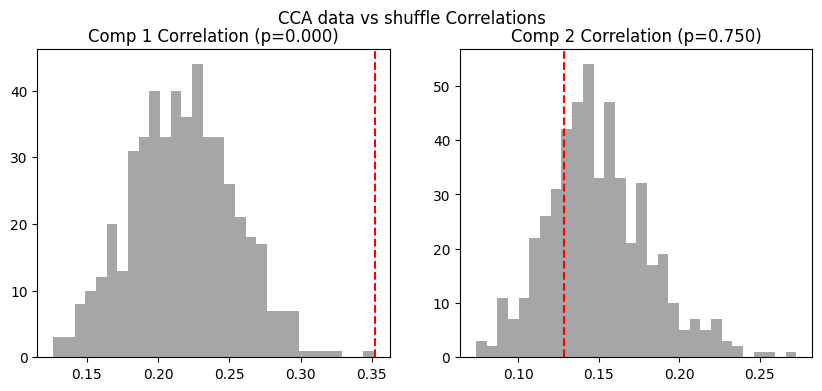

In [52]:
# plot the same for corr
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for comp in range(2):
    ax = axes[comp]
    ax.hist(
        shuffle_results_df[f'corr_{comp}'],
        bins=30, color='gray', alpha=0.7
    )
    ax.axvline(
        x=result_ori['corrs'][comp],
        color='red', linestyle='--',
        label='Original CCA'
    )
    p_value = np.mean(
        shuffle_results_df[f'corr_{comp}'] >=
        result_ori['corrs'][comp]
    )
    ax.set_title(f'Comp {comp+1} Correlation (p={p_value:.3f})')
plt.suptitle(f'CCA data vs shuffle Correlations')
plt.savefig(
    os.path.join(target_folder, f'CCA_shuffle_correlation.pdf'),
    bbox_inches='tight'
)

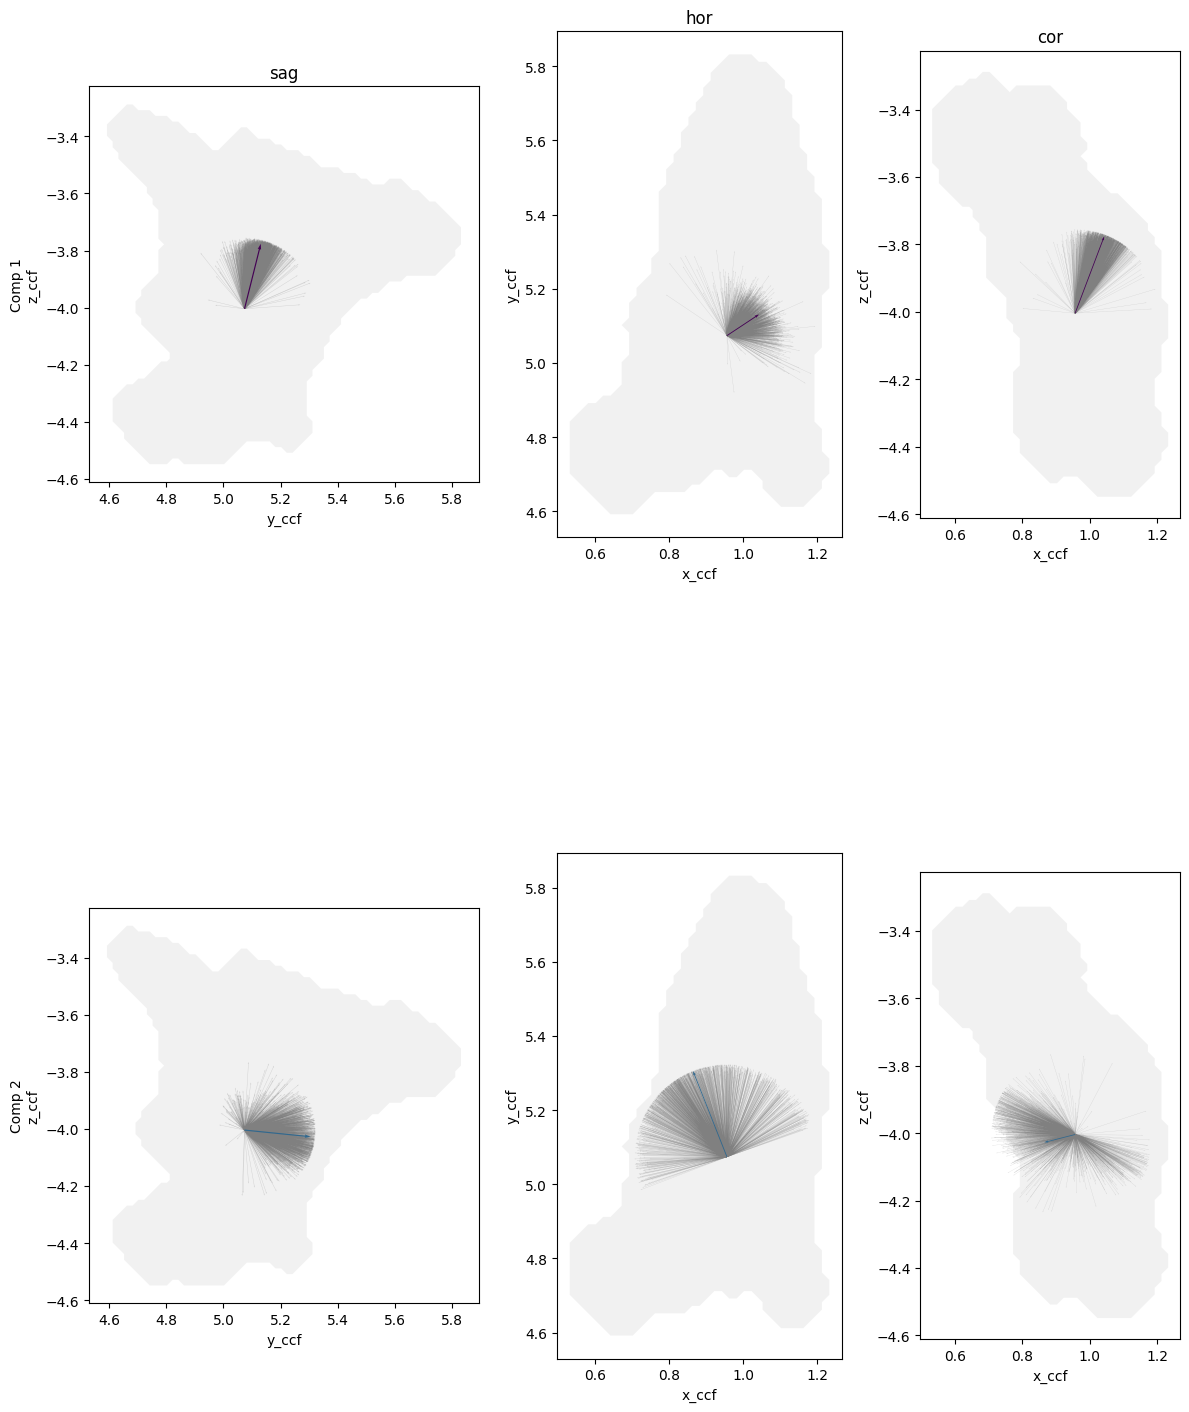

In [53]:

# Plot
fig, axes = plt.subplots(2, 3, figsize=(12, 18), width_ratios=[1.5, 1.1, 1])

# Extract and normalize CCA component vectors
cca_vecs = result_ori['cca_y_weights'].copy()
cca_vecs = cca_vecs / np.linalg.norm(cca_vecs, axis=0, keepdims=True)

# Optional: mean of CCF as the origin
# origin = np.nanmean(ccf_mat, axis=0)

axis_labels = ['x_ccf', 'y_ccf', 'z_ccf']

for comp in range(2):   # row index → component number
    for plane_ind, plane in enumerate(planes.keys()):  # column index → plane
        ax = axes[comp, plane_ind]

        ix, iy = planes[plane]

        # anatomical mesh
        # ax.scatter(
        #     mesh_vertices_lps[:, ix],
        #     mesh_vertices_lps[:, iy],
        #     color='lightgray',
        #     alpha=0.1,
        #     s=0.2
        # )
        for c in mesh_contours[plane]:
            ax.fill(c[:, 0], c[:, 1], color='lightgray', alpha=0.3, linewidth=0)

        # ax.quiver(origin[planes[plane][0]], origin[planes[plane][1]],
        #     vec[planes[plane][0]], vec[planes[plane][1]],
        #     angles='xy', scale_units='xy', scale=3, label=f'CCA CCF Comp {i+1}', color=cm.viridis(i/3))

        # ---------- BOOTSTRAP VECTOR CLOUD ----------
        for b in range(n_boot):
            vec = result_ori['boot_yw'][b, :, comp]

            ax.quiver(
                origin[ix], origin[iy],
                vec[ix], vec[iy],
                angles='xy',
                scale_units='xy',
                scale=1/0.25,
                color=[0.5, 0.5, 0.5],
                alpha=0.3,      # transparent bootstrap vectors
                width=0.001,
                linewidth=0.01
            )

        # ---------- ORIGINAL CCA VECTOR (THICK) ----------
        vec0 = cca_vecs[:, comp]

        ax.quiver(
            origin[ix], origin[iy],
            vec0[ix], vec0[iy],
            angles='xy',
            scale_units='xy',
            scale=1/0.25,
            color=cm.viridis(comp / 3),
            width=0.003,
            linewidth=0.25,
            label=f'Comp {comp+1}'
        )

        # labels & style
        ax.set_xlabel(axis_labels[ix])
        ax.set_ylabel(axis_labels[iy])
        ax.set_aspect('equal')

        if comp == 0:
            ax.set_title(f'{plane}')

        if plane_ind == 0:
            ax.set_ylabel(f'Comp {comp+1}\n{axis_labels[iy]}')

        # ax.legend(loc='upper left')

plt.tight_layout()
plt.savefig(
    os.path.join(target_folder, 'CCA_CCF_components_bootstrap_3x3.pdf'),
    bbox_inches='tight'
)
plt.show()



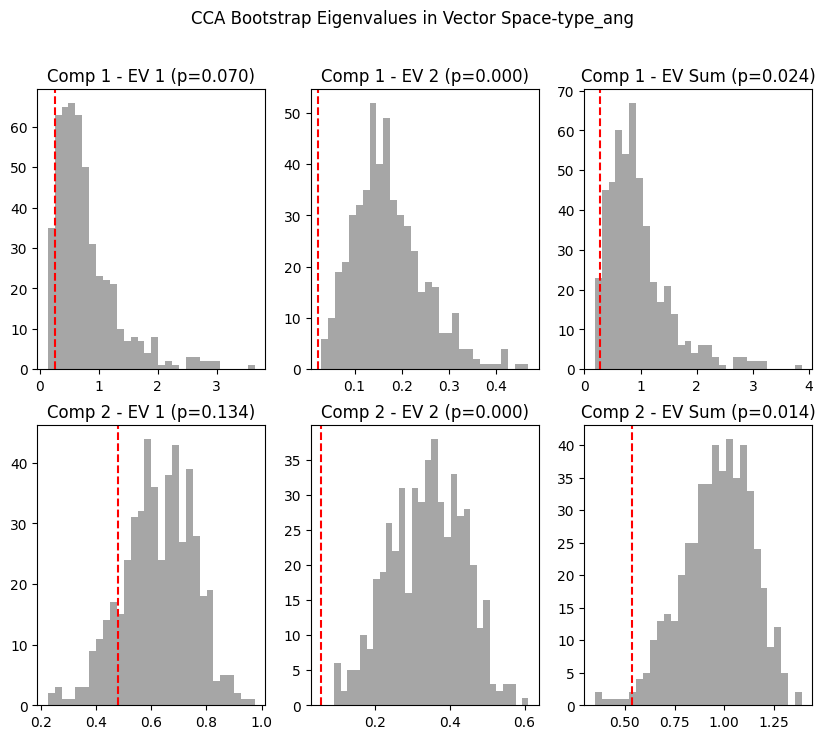

In [54]:

fig, axes = plt.subplots(2, 3, figsize=(10, 8))
# Plot eigenvalue distributions for vector space
type = 'ang'
for comp in range(2):
    for eigen_int in range(2):
        ax = axes[comp, eigen_int]
        ax.hist(
            shuffle_results_df[f'eigvals_{type}_{comp}_{eigen_int+1}'],
            bins=30, color='gray', alpha=0.7
        )
        ax.axvline(
            x=result_ori[f'eigvals_{type}_{comp}'][eigen_int],
            color='red', linestyle='--',
            label='Original CCA'
        )
        p_value = np.mean(
            shuffle_results_df[f'eigvals_{type}_{comp}_{eigen_int+1}'] <=
            result_ori[f'eigvals_{type}_{comp}'][eigen_int]
        )
        ax.set_title(f'Comp {comp+1} - EV {eigen_int+1} (p={p_value:.3f})')
    eigen_sum = result_ori[f'eigvals_{type}_{comp}'].sum()
    eigen_sum_shuffle = shuffle_results_df[[f'eigvals_{type}_{comp}_1', f'eigvals_{type}_{comp}_2']].sum(axis=1)
    p_value = np.mean(eigen_sum_shuffle <= eigen_sum)
    axes[comp, 2].hist(
        eigen_sum_shuffle,
        bins=30, color='gray', alpha=0.7
    )
    axes[comp, 2].axvline(
        x=eigen_sum,
        color='red', linestyle='--',
        label='Original CCA'
    )
    axes[comp, 2].set_title(f'Comp {comp+1} - EV Sum (p={p_value:.3f})')
plt.suptitle(f'CCA Bootstrap Eigenvalues in Vector Space-type_{type}')
# plt.sca(axes[0, 0])
plt.savefig(
    os.path.join(target_folder, f'CCA_shuffle_variance_by_eigenvalues_{type}.pdf'),
    bbox_inches='tight'
)

